# Clinical Trials Data Analysis: COVID-19 Dataset
**Project Overview:** This notebook covers the end-to-end process of auditing, cleaning, and exploring clinical trial data. The goal is to transform raw data into a structured format ready for extracting meaningful insights about trial Landscape, Enrollment, Durations failures.

---

## This book is devided in two parts:

### Part 1: Data Quality Audit & Cleaning

### Part 2: Exploratory Data Analysis 

---

## Setting up

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
       


In [145]:
# Helper functions

# Function to analyze missing values in a specific column
def audit_missing_values(df, column_name):
    '''
    Analyzes the relationship between missing values in a specific column 
    and the 'Study Type' and 'Status' of the clinical trials.
    '''
    # Filter the rows where the specified column is null
    null_subset = df[df[column_name].isna()]
    
    total_nulls = len(null_subset)
    
    if total_nulls == 0:
        print(f"No missing values found in column: '{column_name}'")
        return

    print(f"=== AUDIT REPORT: {column_name.upper()} ===")
    print(f"Total missing values: {total_nulls}")
    print("-" * 30)
    
    # Analyze relationship with Study Type
    print(f"--- Study Type distribution for missing {column_name} ---")
    print(null_subset['Study Type'].value_counts())
    
    # Analyze relationship with Status
    print(f"\n--- Status distribution for missing {column_name} ---")
    print(null_subset['Status'].value_counts())
    print("=" * 40 + "\n")



# Part 1: Data Quality Audit & Cleaning

#### In this section, the goal was to address duplicates and null values

In [ ]:
#loading the dataset
path = os.path.join('..', 'src', 'Data', 'raw', 'COVID clinical trials.csv')
df = pd.read_csv(path)

#setting the display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

#Initial visualization of the dataset
df.head(10)

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,All,"18 Years and older (Adult, Older Adult)",Not Applicable,1000.0,Other,Interventional,Allocation: N/A|Intervention Model: Single Gro...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,All,"18 Years and older (Adult, Older Adult)",Phase 1|Phase 2,60.0,Other,Interventional,Allocation: Randomized|Intervention Model: Par...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,All,"18 Years and older (Adult, Older Adult)",NaN,500.0,Other,Observational,Observational Model: Cohort|Time Perspective: ...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,All,"Child, Adult, Older Adult",NaN,2500.0,Industry,Observational,Observational Model: Cohort|Time Perspective: ...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,Female,18 Years to 48 Years (Adult),NaN,50.0,Other,Observational,Observational Model: Cohort|Time Perspective: ...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924
5,6,NCT04516954,Convalescent Plasma for COVID-19 Patients,CPCP,Enrolling by invitation,No Results Available,COVID 19,Biological: Convalescent COVID 19 Plasma,Evaluate the safety|Change in requirement for ...,Vinmec Research Institute of Stem Cell and Gen...,All,"18 Years to 75 Years (Adult, Older Adult)",Early Phase 1,10.0,Other,Interventional,Allocation: N/A|Intervention Model: Single Gro...,ISC.20.11.1,"August 1, 2020","November 30, 2020","December 30, 2020","August 18, 2020",NaN,"August 20, 2020",Vinmec Research Institute of Stem cell and Gen...,NaN,https://ClinicalTrials.gov/show/NCT04516954
6,7,NCT04476940,COVID-19 Breastfeeding Guideline for African-A...,COVID-BF,Not yet recruiting,No Results Available,Covid19|Exclusive Breastfee

In [147]:
#Overview of the dataset attributes and datatypes
print(df.columns, '\n', '-'*50, '\n')

print(df.info(),'\n','-'*50, '\n')

print('Total research studies:', len(df),'\n','-'*50)

Index(['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results',
       'Conditions', 'Interventions', 'Outcome Measures',
       'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment',
       'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date',
       'Primary Completion Date', 'Completion Date', 'First Posted',
       'Results First Posted', 'Last Update Posted', 'Locations',
       'Study Documents', 'URL'],
      dtype='object') 
 -------------------------------------------------- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 no

In [148]:
# Veryfying of null values
null_summary = df.isnull().sum()
print("Columns with the most missing values:")
print(null_summary[null_summary > 0].sort_values(ascending=False), '\n', '-'*50)

# Verifying of duplicates
print(f"\nDuplicates in NCT Number: {df['NCT Number'].duplicated().sum()}")

Columns with the most missing values:
Results First Posted       5747
Study Documents            5601
Acronym                    3303
Phases                     2461
Interventions               886
Locations                   585
Completion Date              36
Primary Completion Date      36
Outcome Measures             35
Study Designs                35
Start Date                   34
Enrollment                   34
Gender                       10
Other IDs                     1
dtype: int64 
 --------------------------------------------------

Duplicates in NCT Number: 0


In [149]:
df.describe(include='all')


,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
count,5783.000000,5783,5783,2480,5783,5783,5783,4897,5748,5783,5773,5783,3322,5.749000e+03,5783,5783,5748,5782,5749,5747,5747,5783,36,5783,5198,182,5783
unique,NaN,5783,5775,2338,12,2,3067,4337,5687,3631,3,417,8,NaN,26,9,267,5734,654,877,978,438,33,269,4255,182,5783
top,NaN,NCT04785898,Recombinant Human Angiotensin-converting Enzym...,COVID-19,Recruiting,No Results Available,COVID-19,Other: No intervention,Mortality,Assistance Publique - Hôpitaux de Paris,All,"18 Years and older (Adult, Older Adult)",Not Applicable,NaN,Other,Interventional,Observational Model: Cohort|Time Perspective: ...,COVID-19,"May 1, 2020","December 31, 2020","December 31, 2021","April 24, 2020","November 4, 2020","April 8, 2021","Uhmontpellier, Montpellier, France","""Statistical Analysis Plan"", https://ClinicalT...",https://ClinicalTrials.gov/show/NCT04785898
freq,NaN,1,2,47,2805,5747,720,32,5,78,5567,2885,1354,NaN,4488,3322,1011,6,113,122,179,108,2,109,19,1,1
mean,2892.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.831949e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1669.552635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.045437e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1446.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2892.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4337.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.600000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **Data Quality Audit report**

After initial inspection, it is possible to conclude that:

- `Results First Posted` is almost empty, so little can be extracted from it. It should be dropped.

- Both `Results First Posted` and `Last Updated Posted` refer to information that were made public on the clinical trial website and not necessarily when the study actully occured. For tracking chronological data, the columns `Start Date`and `Completion Date` are much more relevant. Therefore they should be dropped.

- `Study Documents`is also almost empty, and for the same reason as before, it will be dropped.

- The `Acronym`column should also be dropped since it is also full of missing values and it only abbreviates the names of the study titles. Since we have column `Title`, `Acronym` will only add redundant information.

- The column `Rank` serves only for indexing, and does not really offer valuable information. It gives the same information as the column `NCT Number` which is more appropriate to be used later on as PK when loading the data into the SQL database.

- Likewise, the column `Other IDs` contains alternative identifiers. It should be dropped to avoid redundancy with the column `NCT Number`

- `URL` is another column that does not bring relevant statistical information, so it will be dropped at this phase.

- The column `Enrollment` only shows integers. It should be modified to integer type.

- Columns `Start Date`, `Primary Completion Date` and `Completion Date` need to be converted to datetime.

- The `Study Designs` column bears information that needs to be split into new columns: `Allocation`, `Intervention_model`, `Masking` and `Primary_purpose`

- The column `Locations` contains concatenated strings with facility names, cities, and countries. The raw format is not suitable for geographical analysis.  

- There are several null values that need to be addressed.

---

### **Dropping unnecessary columns**

In [150]:
# Selecting columns to drop based on high null values and low relevance for analysis
cols_to_drop = ['Acronym', 'Results First Posted', 'Study Documents','Other IDs', 'Rank', 'URL', 'First Posted', 'Last Update Posted']


df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f'Clean dataset: {len(df.columns)}', '\n', '-'*50)
print(f'Dataset columns: {df.columns}', '\n', '-'*50)

Clean dataset: 19 
 --------------------------------------------------
Dataset columns: Index(['NCT Number', 'Title', 'Status', 'Study Results', 'Conditions',
       'Interventions', 'Outcome Measures', 'Sponsor/Collaborators', 'Gender',
       'Age', 'Phases', 'Enrollment', 'Funded Bys', 'Study Type',
       'Study Designs', 'Start Date', 'Primary Completion Date',
       'Completion Date', 'Locations'],
      dtype='object') 
 --------------------------------------------------


---

### **Addressing the Enrollment column**

In [151]:
# Converting Enrollment column to numeric, coercing errors to NaN
df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce').astype('Int64')

#  Checking the datatypes and counts after conversion
df['Enrollment'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5783 entries, 0 to 5782
Series name: Enrollment
Non-Null Count  Dtype
--------------  -----
5749 non-null   Int64
dtypes: Int64(1)
memory usage: 51.0 KB


In [152]:
# Identifying rows with missing values in key date columns
Enroll_null = df[df['Enrollment'].isna()]
Enroll_null

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations
448,NCT04372368,Convalescent Plasma for the Treatment of Patie...,No longer available,No Results Available,COVID-19|SARS-CoV 2,Biological: COVID-19 Convalescent Plasma,NaN,"University of Colorado, Denver",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Children's Hospital Colorado, Aurora, Colorado..."
588,NCT04420988,Investigational COVID-19 Convalescent Plasma I...,Available,No Results Available,COVID-19|SARS-CoV 2|SARS-CoV Infection,Biological: COVID-19 Convalescent Plasma,NaN,"Rutgers, The State University of New Jersey|Un...",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Individual Patients|Intermedia...,NaN,NaN,NaN,NaN,"Rutgers New Jersey Medical School, Newark, New..."
729,NCT04338360,Expanded Access to Convalescent Plasma for the...,Approved for marketing,No Results Available,COVID19,Biological: COVID-19 convalescent plasma,NaN,Mayo Clinic,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,"Mayo Clinic in Arizona, Scottsdale, Arizona, U..."
826,NCT04358211,Expanded Access to Convalescent Plasma to Trea...,No longer available,No Results Available,COVID-19,Biological: Biological: COVID-19 convalescent ...,NaN,"Nakhle Saba, MD|Tulane University",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population|T...,NaN,NaN,NaN,NaN,"Tulane Medical Center, New Orleans, Louisiana,..."
1502,NCT04472572,Expanded Access to Convalescent Plasma for Tre...,Available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,Hackensack Meridian Health,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Hackensack University Medical Center, Hackensa..."
1924,NCT04355793,Expanded Access Program of Ruxolitinib for the...,Available,No Results Available,COVID-19,Drug: Ruxolitinib,NaN,Incyte Corporation,All,"12 Years and older (Child, Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,NaN
2188,NCT04646031,Expanded Access to T89 for Treatment Use in In...,Available,No Results Available,Covid19,Drug: T89 capsule,NaN,"Tasly Pharmaceuticals, Inc.|Tasly Pharmaceutic...",All,"Child, Adult, Older Adult",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,"MultiCare Health System, Tacoma, Washington, U..."
2380,NCT04363034,Arkansas Expanded Access COVID-19 Convalescent...,Temporarily not available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,University of Arkansas,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,NaN
2488,NCT04338347,CAP-1002 in Severe COVID-19 Disease,No longer available,No Results Available,COVID-19,Biological: CAP-1002 Allogeneic Cardiosphere-D...,NaN,Capricor Inc.,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population|T...,NaN,NaN,NaN,NaN,"Cedars-Sinai Medical Center, Los Angeles, Cali..."
2656,NCT04360486,Treatment Of CORONAVIRUS DISEASE 2019 (COVID-1...,Available,No Results Available,Severe Acute Respiratory Syndrome Coronavirus 2,Biological: Anti-Sars-CoV-2 Convalescent Plasma,NaN,U.S. Army Medical Research and Development Com...,All,"Child, Adult, Older Adult",NaN,<NA>,U.S. Fed,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Naval Hospital Camp Pendleton, Oceanside, Cali..."


In [153]:
# Analyzing the distribution of Study Type and Status among the rows with missing values
audit_missing_values(df, 'Enrollment')

=== AUDIT REPORT: ENROLLMENT ===
Total missing values: 34
------------------------------
--- Study Type distribution for missing Enrollment ---
Study Type
Expanded Access:Intermediate-size Population                           15
Expanded Access:Treatment IND/Protocol                                  8
Expanded Access:Intermediate-size Population|Treatment IND/Protocol     5
Expanded Access:Individual Patients                                     3
Expanded Access:Individual Patients|Intermediate-size Population        1
Expanded Access                                                         1
Expanded Access:Individual Patients|Treatment IND/Protocol              1
Name: count, dtype: int64

--- Status distribution for missing Enrollment ---
Status
Available                    19
No longer available          12
Approved for marketing        2
Temporarily not available     1
Name: count, dtype: int64



In [154]:
expanded_access_enrollment = df[df['Study Type'].str.contains('Expanded Access', na=False)].copy()
expanded_access_enrollment

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations
448,NCT04372368,Convalescent Plasma for the Treatment of Patie...,No longer available,No Results Available,COVID-19|SARS-CoV 2,Biological: COVID-19 Convalescent Plasma,NaN,"University of Colorado, Denver",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Children's Hospital Colorado, Aurora, Colorado..."
588,NCT04420988,Investigational COVID-19 Convalescent Plasma I...,Available,No Results Available,COVID-19|SARS-CoV 2|SARS-CoV Infection,Biological: COVID-19 Convalescent Plasma,NaN,"Rutgers, The State University of New Jersey|Un...",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Individual Patients|Intermedia...,NaN,NaN,NaN,NaN,"Rutgers New Jersey Medical School, Newark, New..."
729,NCT04338360,Expanded Access to Convalescent Plasma for the...,Approved for marketing,No Results Available,COVID19,Biological: COVID-19 convalescent plasma,NaN,Mayo Clinic,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,"Mayo Clinic in Arizona, Scottsdale, Arizona, U..."
826,NCT04358211,Expanded Access to Convalescent Plasma to Trea...,No longer available,No Results Available,COVID-19,Biological: Biological: COVID-19 convalescent ...,NaN,"Nakhle Saba, MD|Tulane University",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population|T...,NaN,NaN,NaN,NaN,"Tulane Medical Center, New Orleans, Louisiana,..."
1502,NCT04472572,Expanded Access to Convalescent Plasma for Tre...,Available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,Hackensack Meridian Health,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Hackensack University Medical Center, Hackensa..."
1924,NCT04355793,Expanded Access Program of Ruxolitinib for the...,Available,No Results Available,COVID-19,Drug: Ruxolitinib,NaN,Incyte Corporation,All,"12 Years and older (Child, Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,NaN
2188,NCT04646031,Expanded Access to T89 for Treatment Use in In...,Available,No Results Available,Covid19,Drug: T89 capsule,NaN,"Tasly Pharmaceuticals, Inc.|Tasly Pharmaceutic...",All,"Child, Adult, Older Adult",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,"MultiCare Health System, Tacoma, Washington, U..."
2380,NCT04363034,Arkansas Expanded Access COVID-19 Convalescent...,Temporarily not available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,University of Arkansas,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaN,NaN,NaN,NaN
2488,NCT04338347,CAP-1002 in Severe COVID-19 Disease,No longer available,No Results Available,COVID-19,Biological: CAP-1002 Allogeneic Cardiosphere-D...,NaN,Capricor Inc.,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population|T...,NaN,NaN,NaN,NaN,"Cedars-Sinai Medical Center, Los Angeles, Cali..."
2656,NCT04360486,Treatment Of CORONAVIRUS DISEASE 2019 (COVID-1...,Available,No Results Available,Severe Acute Respiratory Syndrome Coronavirus 2,Biological: Anti-Sars-CoV-2 Convalescent Plasma,NaN,U.S. Army Medical Research and Development Com...,All,"Child, Adult, Older Adult",NaN,<NA>,U.S. Fed,Expanded Access:Treatment IND/Protocol,NaN,NaN,NaN,NaN,"Naval Hospital Camp Pendleton, Oceanside, Cali..."


#### **Data audit for the `Enrollment` column**

A total of 34 missing values were detected for the column `Enrollment`. Analysis shows that there are associated with *Expanded Access* studies. Unlike traditional trials, these programs provide compassionate treatment instead of meeting specifica recruitment targets, which explains the missing enrollment figures. These values will be left as NaN

---

### **Addressing the Date formats**

In [155]:
# Converting date columns to datetime format
cols_data = ['Start Date', 'Primary Completion Date', 'Completion Date']

for col in cols_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Checking the date format after conversion
df[cols_data].head()


C:\Users\User\AppData\Local\Temp\ipykernel_27796\3881056000.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\User\AppData\Local\Temp\ipykernel_27796\3881056000.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\User\AppData\Local\Temp\ipykernel_27796\3881056000.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


,Start Date,Primary Completion Date,Completion Date
0,2020-11-09,2020-12-22,2021-04-30
1,2020-11-02,2020-12-15,2021-01-29
2,2020-05-07,2021-06-15,2021-06-15
3,2020-05-25,2020-07-31,2020-08-31
4,2020-05-05,2021-05-01,2021-05-01


In [156]:
# Rechecking the datatypes and counts after date conversion
print(df[cols_data].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start Date               5749 non-null   datetime64[ns]
 1   Primary Completion Date  5747 non-null   datetime64[ns]
 2   Completion Date          5747 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 135.7 KB
None


In [157]:
# Identifying rows with missing values in key date columns
df[df['Start Date'].isna() | df['Primary Completion Date'].isna() | df['Completion Date'].isna()]



,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations
448,NCT04372368,Convalescent Plasma for the Treatment of Patie...,No longer available,No Results Available,COVID-19|SARS-CoV 2,Biological: COVID-19 Convalescent Plasma,NaN,"University of Colorado, Denver",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaT,NaT,NaT,"Children's Hospital Colorado, Aurora, Colorado..."
588,NCT04420988,Investigational COVID-19 Convalescent Plasma I...,Available,No Results Available,COVID-19|SARS-CoV 2|SARS-CoV Infection,Biological: COVID-19 Convalescent Plasma,NaN,"Rutgers, The State University of New Jersey|Un...",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Individual Patients|Intermedia...,NaN,NaT,NaT,NaT,"Rutgers New Jersey Medical School, Newark, New..."
729,NCT04338360,Expanded Access to Convalescent Plasma for the...,Approved for marketing,No Results Available,COVID19,Biological: COVID-19 convalescent plasma,NaN,Mayo Clinic,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaT,NaT,NaT,"Mayo Clinic in Arizona, Scottsdale, Arizona, U..."
826,NCT04358211,Expanded Access to Convalescent Plasma to Trea...,No longer available,No Results Available,COVID-19,Biological: Biological: COVID-19 convalescent ...,NaN,"Nakhle Saba, MD|Tulane University",All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population|T...,NaN,NaT,NaT,NaT,"Tulane Medical Center, New Orleans, Louisiana,..."
1502,NCT04472572,Expanded Access to Convalescent Plasma for Tre...,Available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,Hackensack Meridian Health,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Treatment IND/Protocol,NaN,NaT,NaT,NaT,"Hackensack University Medical Center, Hackensa..."
1924,NCT04355793,Expanded Access Program of Ruxolitinib for the...,Available,No Results Available,COVID-19,Drug: Ruxolitinib,NaN,Incyte Corporation,All,"12 Years and older (Child, Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Treatment IND/Protocol,NaN,NaT,NaT,NaT,NaN
2188,NCT04646031,Expanded Access to T89 for Treatment Use in In...,Available,No Results Available,Covid19,Drug: T89 capsule,NaN,"Tasly Pharmaceuticals, Inc.|Tasly Pharmaceutic...",All,"Child, Adult, Older Adult",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population,NaN,NaT,NaT,NaT,"MultiCare Health System, Tacoma, Washington, U..."
2380,NCT04363034,Arkansas Expanded Access COVID-19 Convalescent...,Temporarily not available,No Results Available,COVID-19,Biological: Convalescent Plasma,NaN,University of Arkansas,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Other,Expanded Access:Intermediate-size Population,NaN,NaT,NaT,NaT,NaN
2488,NCT04338347,CAP-1002 in Severe COVID-19 Disease,No longer available,No Results Available,COVID-19,Biological: CAP-1002 Allogeneic Cardiosphere-D...,NaN,Capricor Inc.,All,"18 Years and older (Adult, Older Adult)",NaN,<NA>,Industry,Expanded Access:Intermediate-size Population|T...,NaN,NaT,NaT,NaT,"Cedars-Sinai Medical Center, Los Angeles, Cali..."
2656,NCT04360486,Treatment Of CORONAVIRUS DISEASE 2019 (COVID-1...,Available,No Results Available,Severe Acute Respiratory Syndrome Coronavirus 2,Biological: Anti-Sars-CoV-2 Convalescent Plasma,NaN,U.S. Army Medical Research and Development Com...,All,"Child, Adult, Older Adult",NaN,<NA>,U.S. Fed,Expanded Access:Treatment IND/Protocol,NaN,NaT,NaT,NaT,"Naval Hospital Camp Pendleton, Oceanside, Cali..."


In [158]:
# Analyzing the distribution of Study Type and Status among the rows with missing values
audit_missing_values(df, 'Start Date')
audit_missing_values(df, 'Primary Completion Date')
audit_missing_values(df, 'Completion Date')

=== AUDIT REPORT: START DATE ===
Total missing values: 34
------------------------------
--- Study Type distribution for missing Start Date ---
Study Type
Expanded Access:Intermediate-size Population                           15
Expanded Access:Treatment IND/Protocol                                  8
Expanded Access:Intermediate-size Population|Treatment IND/Protocol     5
Expanded Access:Individual Patients                                     3
Expanded Access:Individual Patients|Intermediate-size Population        1
Expanded Access                                                         1
Expanded Access:Individual Patients|Treatment IND/Protocol              1
Name: count, dtype: int64

--- Status distribution for missing Start Date ---
Status
Available                    19
No longer available          12
Approved for marketing        2
Temporarily not available     1
Name: count, dtype: int64

=== AUDIT REPORT: PRIMARY COMPLETION DATE ===
Total missing values: 36
----------------

In [159]:
dates_null = df[df['Primary Completion Date'].isnull() & df['Completion Date'].isnull()]

In [160]:
# Isolating the Status for Observational studies with missing `Primary Completion Date` and `Completion Date` values
obs_list = dates_null[dates_null['Study Type'] == 'Observational']
print(obs_list[['NCT Number', 'Status']])

       NCT Number      Status
5189  NCT01306084  Recruiting
5713  NCT01087333  Recruiting


#### **Data audit for the Dates**

After investigating the missing dates it was concluded that most are associated to Expanded Access programs which, as mentioned  before, operate under special conditions. Commonly, they don't follow strict chronological rules

There were 2 cases identified as Observational studies with missing `Primary Completion Date` and `Completion Date` fields. After isolating them, it was concluded that these studies are still in the recruiting phase, which explains the missing values.

Missing values will be left as NaT

---

### **Addressing the `Study Designs` split**

In [161]:
# Function to extract specific values from the 'Study Designs' string
def extract_design_attribute(text, attribute):
    '''
    Extracts specific attributes from a concatenated string.
    
    The 'Study Designs' column in the raw dataset contains multiple key-value pairs separated by pipes (|). 
    This function parses the string, identifies the requested attribute (e.g., 'Masking:', 'Allocation:'), and returns the corresponding clean value.
    
    Parameters:
    text (str): The raw string from the 'Study Designs' column.
    attribute (str): The label to search for within the string.
    
    Returns:
    str: The extracted attribute value, or None if the attribute is not found or the input text is null.
    '''
    if pd.isna(text):
        return None
    # Split the string by the pipe '|' character
    parts = text.split('|')
    for part in parts:
        if attribute in part:
            # Remove the label and return the clean value
            return part.replace(attribute, '').strip()
    return None

# Applying the extraction to create 4 new clean columns
df['allocation'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Allocation:'))
df['intervention_model'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Intervention Model:'))
df['observational_model'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Observational Model:'))
df['time_perspective'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Time Perspective:'))
df['masking'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Masking:'))
df['primary_purpose'] = df['Study Designs'].apply(lambda x: extract_design_attribute(x, 'Primary Purpose:'))

# Check the new columns
df[['NCT Number', 'allocation', 'intervention_model', 'observational_model', 'time_perspective', 'masking', 'primary_purpose']].head(10)

,NCT Number,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose
0,NCT04785898,N/A,Single Group Assignment,None,None,None (Open Label),Diagnostic
1,NCT04595136,Randomized,Parallel Assignment,None,None,"Triple (Participant, Care Provider, Investigator)",Treatment
2,NCT04395482,None,None,Cohort,Retrospective,None,None
3,NCT04416061,None,None,Cohort,Retrospective,None,None
4,NCT04395924,None,None,Cohort,Prospective,None,None
5,NCT04516954,N/A,Single Group Assignment,None,None,None (Open Label),Treatment
6,NCT04476940,N/A,Single Group Assignment,None,None,None (Open Label),Prevention
7,NCT04634214,None,None,Case-Control,Retrospective,None,None
8,NCT04602884,Non-Randomized,Parallel Assignment,None,None,None (Open Label),Diagnostic
9,NCT04384588,Non-Randomized,Parallel Assignment,None,None,None (Open Label),Treatment


In [162]:
# Analyzing the distribution of Study Type and Status among the rows with missing values in the new columns
audit_missing_values(df, 'allocation')
audit_missing_values(df, 'intervention_model')
audit_missing_values(df, 'observational_model')
audit_missing_values(df, 'time_perspective')
audit_missing_values(df, 'masking')
audit_missing_values(df, 'primary_purpose')

=== AUDIT REPORT: ALLOCATION ===
Total missing values: 2464
------------------------------
--- Study Type distribution for missing allocation ---
Study Type
Observational                                                          2427
Expanded Access:Intermediate-size Population                             15
Expanded Access:Treatment IND/Protocol                                    8
Expanded Access:Intermediate-size Population|Treatment IND/Protocol       5
Interventional                                                            3
Expanded Access:Individual Patients                                       3
Expanded Access:Individual Patients|Intermediate-size Population          1
Expanded Access                                                           1
Expanded Access:Individual Patients|Treatment IND/Protocol                1
Name: count, dtype: int64

--- Status distribution for missing allocation ---
Status
Recruiting                   1225
Completed                     565
Not ye

In [163]:
# Investigating the Interventional studies with missing 'Allocation' values
df[(df['Study Type'] == 'Interventional') & (df['allocation'].isna())]


,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose
780,NCT04405934,COG-UK Project Hospital-Onset COVID-19 Infecti...,Not yet recruiting,No Results Available,Covid-19|Nosocomial Infection|Coronavirus|Coro...,Other: Use of virus (Covid-19) genome sequence...,Incidence rates of IPC-defined hospital-onset ...,"University College, London|Public Health England",All,"Child, Adult, Older Adult",Not Applicable,2000,Other,Interventional,Intervention Model: Sequential Assignment|Mask...,2020-07-01,2020-10-01,2021-04-01,NaN,None,Sequential Assignment,None,None,None (Open Label),Health Services Research
5137,NCT04394039,Post-Pandemic Perception of Public Space in Si...,Not yet recruiting,No Results Available,Stress|Anxiety,Other: Public space exposure,EEG power in alpha band|EEG power in beta band...,"National University, Singapore|National Univer...",All,"21 Years to 75 Years (Adult, Older Adult)",Not Applicable,34,Other,Interventional,Intervention Model: Sequential Assignment|Mask...,2020-06-01,2020-08-01,2020-12-31,Institute for Health Innovation & Technology (...,None,Sequential Assignment,None,None,None (Open Label),Supportive Care
5603,NCT03724045,Back Side of the Moon: Nutritional Therapy,Recruiting,No Results Available,Nutritional Deficiency|Hospitalism,Dietary Supplement: Back Side of the Moon,Morbidity|Mortality,Universitair Ziekenhuis Brussel|Baxter Healthc...,All,"18 Years and older (Adult, Older Adult)",Not Applicable,50,Other|Industry,Interventional,Intervention Model: Sequential Assignment|Mask...,2019-01-01,2021-10-01,2021-10-01,"UZ Brussel, Jette, Belgium",None,Sequential Assignment,None,None,None (Open Label),Prevention


In [164]:
# Inspecting the overall Interventional studies with 'Sequential Assignment' intervention model
df[df['intervention_model'] == 'Sequential Assignment'][['Study Type', 'intervention_model', 'allocation']]

,Study Type,intervention_model,allocation
124,Interventional,Sequential Assignment,Non-Randomized
129,Interventional,Sequential Assignment,Non-Randomized
229,Interventional,Sequential Assignment,Non-Randomized
290,Interventional,Sequential Assignment,N/A
380,Interventional,Sequential Assignment,Randomized
...,...,...,...
5590,Interventional,Sequential Assignment,Randomized
5603,Interventional,Sequential Assignment,None
5720,Interventional,Sequential Assignment,Randomized
5731,Interventional,Sequential Assignment,Randomized


In [165]:
# Investigating the Observational studies with missing 'observational_model' values
df[(df['Study Type'] == 'Observational') & (df['observational_model'].isna())]

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose
2330,NCT04389645,Interferon Gamma Induced Protein 10 (IP-10) in...,Completed,No Results Available,COVID-19,Diagnostic Test: IP-10 in CDS protocol,IP-10 levels,MeMed Diagnostics Ltd.,All,"18 Years and older (Adult, Older Adult)",NaN,52,Industry,Observational,NaN,2020-04-07,2020-05-12,2020-05-12,"Rabin Medical Center, Petach Tikva, Israel",None,None,None,None,None,None


#### **Data audit for the `Study Designs` attributes**

The original `Study Designs` column was parsed to extract six distinct methodology attributes. This process revealed a structured pattern of missing values that aligns with the fundamental differences between study types:

- Interventional-only attributes - `allocation`, `intervention_model`, `masking` and `primary_purpose`
    - The majority of the missing values correspond to Observational studies, where these attributes don't apply.
    - A minority of the missing values correspond to Expanded Access studies, which often follow different experimental research protocols, thereby explaining the lack of a standardized study design structure.
    - 3 Interventional studies were missing `allocation` values. For these studies allocation is probably non-applicable. Missing values should be replaced with N/A  

- Observational-only attributes - `observational_model`, `time_perspective`
    - The majority of the missing values correspond to Interventional studies, where these attributes don't apply.
    - A minority of the missing values correspond to Expanded Access studies -> different design structure
    - 1 Observational study were missing `observational_model` and `time_perspective` values. This happened because the source column `Study Designs` was already missing. In this case, it appears to be an outlier. Missing values should be replaced with N/A  



In [166]:
# Filling the missing values in the new design columns with 'N/A' for a more systematic approach
design_cols = ['allocation', 'intervention_model', 'observational_model', 'time_perspective', 'masking', 'primary_purpose']

df[design_cols] = df[design_cols].fillna('N/A')

# Confirming that all missing values in the new design columns have been filled
audit_missing_values(df, 'allocation')
audit_missing_values(df, 'intervention_model')
audit_missing_values(df, 'masking') 
audit_missing_values(df, 'primary_purpose')
audit_missing_values(df, 'observational_model')
audit_missing_values(df, 'time_perspective')

No missing values found in column: 'allocation'
No missing values found in column: 'intervention_model'
No missing values found in column: 'masking'
No missing values found in column: 'primary_purpose'
No missing values found in column: 'observational_model'
No missing values found in column: 'time_perspective'


 ---

### **Addressing the `Locations` column**

In [167]:
# Creating a new column 'country' by extracting the country name from the 'Locations' column
def extract_country(location):
    '''
    Extracts the country name from a complex location string.
    
    The 'Locations' column contains multiple information about facilities, cities, sometimes states, and countries.
    Some entries contain multiple locations separated by pipes (|) and detailed addresses separated by commas. 
    This function isolates the first listed facility and retrieves the last element of its address string, which represents the country.
    
    Parameters:
    location (str): The raw string from the 'Locations' column.
    
    Returns:
    str: The extracted country name, or None if the input is null or invalid.
    '''
    if pd.isna(location):
        return None
    
    # Split by pipe '|' and take the first address
    first_addr = str(location).split('|')[0]
    
    # Split by commas and take the last part (country)
    parts = first_addr.split(',')
    country = parts[-1].strip()
    
    return country

# Applying the function to create a new 'country' column
df['country'] = df['Locations'].apply(extract_country)

# Check the new 'country' column
df['country'].head(10)

0           France
1         Colombia
2            Italy
3        Hong Kong
4           France
5          Vietnam
6    United States
7            India
8           Israel
9            Chile
Name: country, dtype: object

In [168]:
# Analyzing the distribution of Study Type and Status among the rows with missing values in the new column
audit_missing_values(df, 'country')

=== AUDIT REPORT: COUNTRY ===
Total missing values: 585
------------------------------
--- Study Type distribution for missing country ---
Study Type
Interventional                                                         353
Observational                                                          218
Expanded Access:Intermediate-size Population                             6
Expanded Access:Individual Patients                                      3
Expanded Access:Treatment IND/Protocol                                   2
Expanded Access                                                          1
Expanded Access:Intermediate-size Population|Treatment IND/Protocol      1
Expanded Access:Individual Patients|Treatment IND/Protocol               1
Name: count, dtype: int64

--- Status distribution for missing country ---
Status
Not yet recruiting           523
Withdrawn                     41
Available                      8
No longer available            5
Completed                      3
Act

In [169]:
# Isolating the 'edge cases': missing location but study should have one
# Defining the main statuses we already investigated
main_drivers = ['Not yet recruiting', 'Withdrawn']

# Filtering: Country is null AND Status is NOT in our main drivers
edge_cases_loc = df[df['country'].isna() & ~df['Status'].isin(main_drivers)]

# Showing the result to justify the 'Unknown' strategy
print(f"--- Investigation of Residual Missing Locations cases ---")
print(edge_cases_loc[['Study Type', 'Status']].value_counts())

--- Investigation of Residual Missing Locations cases ---
Study Type                                                           Status                   
Observational                                                        Completed                    3
                                                                     Active, not recruiting       3
Expanded Access:Intermediate-size Population                         Available                    3
Expanded Access:Individual Patients                                  No longer available          2
Expanded Access:Treatment IND/Protocol                               Available                    2
Expanded Access:Intermediate-size Population                         No longer available          2
Expanded Access                                                      No longer available          1
Expanded Access:Individual Patients                                  Available                    1
Expanded Access:Individual Patients|Treatment I

In [170]:
# Looking closer to the observational edge cases
# Isolating only the Observational studies within the edge cases
obs_edge_cases = edge_cases_loc[edge_cases_loc['Study Type'] == 'Observational'].copy()

# Defining the columns of design to analyze
design_cols = ['observational_model', 'time_perspective']


obs_edge_cases[design_cols]

,observational_model,time_perspective
1385,Case-Control,Retrospective
1652,Cohort,Retrospective
5018,Cohort,Other
5283,Cohort,Other
5305,Case-Control,Prospective
5462,Cohort,Prospective


#### **Data audit for the `Location` -> `country` attributes**

After converting the format of the column `Locations` to a more suitable standerdized geographic string, there were still 585 cases in which location was missing.

Analysing those cases, the vast majority corresponded to studies that are not yet recruiting or withdrawn which explains the lack of location.

Looking closely to the remaining cases, 14 are related to Expanded Acess studies, which often reflect a decentralized nature of the study.

Observational studies showed 6 missing values, of which 2 corresponded to retrospective studies, which rely on pre-existing medical records and databases rather than active participant recruitment, making a physical location non-applicable. The remaining cases may involve remote or decentralized data collection, which equally justifies the absence of a specific location.

The one intervention study lacking location was terminated, most likely prematurely.

Missing values will be filled with 'Unkown'

In [171]:
# Filling the missing values in the 'country' column with 'Unknown' 
df['country'] = df['country'].fillna('Unknown')

# Confirming that all missing values in the 'country' column have been filled
audit_missing_values(df, 'country')

No missing values found in column: 'country'


 ---

### **Addressing the missing values for the remaining columns: `Phases`, `Gender`, `Interventions` and `Outcome Measures`**

In [172]:
# Analyzing the distribution of Study Type and Status among the rows with missing values
audit_missing_values(df, 'Phases')
audit_missing_values(df, 'Gender')
audit_missing_values(df, 'Interventions')
audit_missing_values(df, 'Outcome Measures')

=== AUDIT REPORT: PHASES ===
Total missing values: 2461
------------------------------
--- Study Type distribution for missing Phases ---
Study Type
Observational                                                          2427
Expanded Access:Intermediate-size Population                             15
Expanded Access:Treatment IND/Protocol                                    8
Expanded Access:Intermediate-size Population|Treatment IND/Protocol       5
Expanded Access:Individual Patients                                       3
Expanded Access:Individual Patients|Intermediate-size Population          1
Expanded Access                                                           1
Expanded Access:Individual Patients|Treatment IND/Protocol                1
Name: count, dtype: int64

--- Status distribution for missing Phases ---
Status
Recruiting                   1224
Completed                     565
Not yet recruiting            350
Active, not recruiting        175
Enrolling by invitation   

In [173]:
# Inspecting the rows with missing gender values
missing_gender_df = df[df['Gender'].isna()].copy()
missing_gender_df

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,Locations,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose,country
156,NCT04452682,The Impact of COVID-19 Pandemic on Critical Li...,Completed,No Results Available,COVID|Critical Limb Ischemia,Other: COVID 19 impact,The ICU admission with associated Pneumonia|Im...,Mansoura University,NaN,"Child, Adult, Older Adult",NaN,998,Other,Observational,Observational Model: Case-Only|Time Perspectiv...,2020-05-25,2020-06-21,2020-06-21,"Mansoura university, Mansoura, Egypt",N/A,N/A,Case-Only,Retrospective,N/A,N/A,Egypt
484,NCT04367896,COVID-19 OUTBREAK AND SOLID ORGAN TRANSPLANTAT...,Completed,No Results Available,COVID-19 OUTBREAK AND SOLID ORGAN TRANSPLANTATION,Other: Survey Group,Management of Solid Organ Transplant during CO...,Fondazione Policlinico Universitario Agostino ...,NaN,"Child, Adult, Older Adult",NaN,1819,Other,Observational,Observational Model: Other|Time Perspective: P...,2020-03-24,2020-04-17,2020-04-17,"Fondazione Policlinico Universitario ""Agostino...",N/A,N/A,Other,Prospective,N/A,N/A,Italy
1190,NCT04618861,Surfactant Protein D Levels in Covid-19 Infect...,Completed,No Results Available,Covid19|Pneumonia|Surfactant Protein Deficiency,NaN,Meassuring the serum surfactant protein D leve...,Kafkas University,NaN,"18 Years and older (Adult, Older Adult)",NaN,127,Other,Observational,Observational Model: Case-Control|Time Perspec...,2020-10-13,2020-11-02,2020-11-02,"Aylin Koseler, Denizli, Outside Of The US, Turkey",N/A,N/A,Case-Control,Cross-Sectional,N/A,N/A,Turkey
1345,NCT04542954,Optimized Management of Covid-19 Positive Kidn...,Completed,No Results Available,Covid19|Kidney Transplant Infection|Risk Facto...,Other: Optimized Management of Covid-19 Positi...,patient outcome|Kidney graft outcome|risk fact...,Hamid Al-Essa Organ Transplant Center|Ministry...,NaN,"Child, Adult, Older Adult",NaN,104,Other,Observational,Observational Model: Cohort|Time Perspective: ...,2020-03-01,2020-08-31,2020-08-31,"OTC, MOH , Kuwait, Kuwait, Kuwait",N/A,N/A,Cohort,Other,N/A,N/A,Kuwait
3808,NCT04444531,Ozone Therapy and Coronavirus Disease of 2019 ...,Completed,No Results Available,COVID-19 Pneumonia,NaN,Time to clinical improvement|Rate of patients ...,Institut d'Investigació Biomèdica de Girona Dr...,NaN,"Child, Adult, Older Adult",NaN,18,Other,Observational,Observational Model: Cohort|Time Perspective: ...,2020-03-20,2020-05-19,2020-05-26,"Policlinic Ibiza Hospital, Ibiza, Spain",N/A,N/A,Cohort,Prospective,N/A,N/A,Spain
4530,NCT04617535,Compassionate Use of REGN-COV2 for the Treatme...,Available,No Results Available,Covid19,Drug: REGN10933+REGN10987 combination therapy,NaN,Regeneron Pharmaceuticals,NaN,"Child, Adult, Older Adult",NaN,<NA>,Industry,Expanded Access:Individual Patients,NaN,NaT,NaT,NaT,NaN,N/A,N/A,N/A,N/A,N/A,N/A,Unknown
4949,NCT04382508,Coronavirus Infection in Primary or Secondary ...,Enrolling by invitation,No Results Available,Immune Suppression|Immune Deficiency|Infection...,Other: Questionnaire,To describe COVID19 infection in children/adul...,University Hospital Southampton NHS Foundation...,NaN,"Child, Adult, Older Adult",NaN,1500,Other,Observational,Observational Model: Cohort|Time Perspective: ...,2020-03-22,2021-03-21,2021-03-21,"University Hospital Southampton NHS FT, Southa...",N/A,N/A,Cohort,Prospective,N/A,N/A,United Kingdom
5048,NCT04817657,Pre-approval Access for Janssen's COVID Vaccin...,No longer available,No Results Available,Healthy,Biological: Ad26.COV2.S,NaN,"Janssen Research & Development, LLC",NaN,"Child, Adult, Older Adult",NaN,<NA>,Industry,Expanded Access:Individual Patients,NaN,NaT,NaT,NaT,NaN,N/A,N/A,N/A,N/A,N/A,N/A,Unknown
5251,NCT04363788,Needle Stick Injuries in Emergency Medical Ser...,Completed,No Results Available,Cardiac Arrest|N

#### **Data audit for the `Phases`, `Gender`, `Interventions` and `Outcome Measures` attributes**

 - `Phases`: All missig values corresponded to Observational and Expanded access studies which is expected as these don't follow normal clinical trial phase structures. Missig values should be filled with N/A

 - `Interventions`: All missig values corresponded to Observational. Missig values should be filled with N/A

 - `Outcome Measures`: Missing values corresponde mostly to Expanded Access studies (except one). Missig values should be filled with N/A

 - `Gender`: Missing values occur mostly on completed Observational studies. Probably gender was not a relevant variable. Missig values should be filled with All



In [174]:
#Filling the missing values in the 'Phases', 'Interventions', and 'Outcome Measures' with 'N/A'
na_cols = ['Phases', 'Interventions', 'Outcome Measures']

for col in na_cols:
    df[col] = df[col].fillna('N/A')

# Replacing 'Not Applicable' with 'N/A' in the 'Phases' column for consistency
df['Phases'] = df['Phases'].replace('Not Applicable', 'N/A')

# Filling with 'All'
df['Gender'] = df['Gender'].fillna('All')

# 3. Final verification to ensure no nulls remain in these columns
audit_missing_values(df, 'Phases')
audit_missing_values(df, 'Interventions')
audit_missing_values(df, 'Outcome Measures')
audit_missing_values(df, 'Gender')

No missing values found in column: 'Phases'
No missing values found in column: 'Interventions'
No missing values found in column: 'Outcome Measures'
No missing values found in column: 'Gender'


In [175]:
# Dropping `Study Designs` and `Locations` columns as they have been decomposed into more structured and clean columns
# These columns are no longer needed for analysis and may contain redundant information after the extraction of design attributes and country.
df.drop(columns=['Study Designs', 'Locations'], inplace=True, errors='ignore')

In [176]:
# Final overview of the cleaned dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   NCT Number               5783 non-null   object        
 1   Title                    5783 non-null   object        
 2   Status                   5783 non-null   object        
 3   Study Results            5783 non-null   object        
 4   Conditions               5783 non-null   object        
 5   Interventions            5783 non-null   object        
 6   Outcome Measures         5783 non-null   object        
 7   Sponsor/Collaborators    5783 non-null   object        
 8   Gender                   5783 non-null   object        
 9   Age                      5783 non-null   object        
 10  Phases                   5783 non-null   object        
 11  Enrollment               5749 non-null   Int64         
 12  Funded Bys               5783 non-

 ---
 ---

# Part 2: Exploratory Analysis

#### In this section, the goal was to perform statistical exploration and visualization of the dataset to identify patterns in clinical trial development and execution.

In [177]:
# Inspecting the statistical summary of the cleaned dataset
df.describe()

,Enrollment,Start Date,Primary Completion Date,Completion Date
count,5749.0,5749,5747,5747
mean,18319.488607,2020-07-14 10:44:43.875456768,2021-06-05 23:08:23.010266368,2021-09-07 09:01:28.324343296
min,0.0,1998-01-01 00:00:00,2016-05-31 00:00:00,2018-05-25 00:00:00
25%,60.0,2020-04-24 00:00:00,2020-10-20 00:00:00,2020-12-06 00:00:00
50%,170.0,2020-07-01 00:00:00,2021-04-01 00:00:00,2021-06-01 00:00:00
75%,560.0,2020-11-20 00:00:00,2021-10-01 00:00:00,2021-12-31 00:00:00
max,20000000.0,2022-01-01 00:00:00,2099-12-31 00:00:00,2099-12-31 00:00:00
std,404543.728784,NaN,NaN,NaN


In [178]:
# Inspecting record with 20M enrollment
df[df['Enrollment'] == df['Enrollment'].max()][['NCT Number', 'Title', 'Study Type', 'Enrollment', 'Conditions']]

,NCT Number,Title,Study Type,Enrollment,Conditions
4728,NCT04644328,The Doctors for Coronavirus Prevention Project...,Interventional,20000000,Covid19


In [179]:
# Inspecting the record with Completion Date on 2099
df[df['Completion Date'] == df['Completion Date'].max()]

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Start Date,Primary Completion Date,Completion Date,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose,country
4612,NCT04342806,Healthcare Worker Exposure Response and Outcom...,Recruiting,No Results Available,Health Care Worker (HCW)|COVID-19,N/A,Number and percent of participants who enroll ...,Duke University|Patient-Centered Outcomes Rese...,All,"18 Years to 89 Years (Adult, Older Adult)",N/A,100000,Other,Observational,2020-04-10,2099-12-31,2099-12-31,N/A,N/A,Cohort,Prospective,N/A,N/A,United States


In [180]:
# Inspecting the record with Start Date on 1998
df[df['Start Date'] == df['Start Date'].min()]

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Start Date,Primary Completion Date,Completion Date,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose,country
5305,NCT04322786,The Use of Angiotensin Converting Enzyme Inhib...,"Active, not recruiting",No Results Available,"Covid-19, Coronavirus, Angiotensin Converting ...",Drug: ACE inhibitor,Incidence of influenza,"University College, London",All,"18 Years and older (Adult, Older Adult)",N/A,1302508,Other,Observational,1998-01-01,2016-05-31,2021-03-31,N/A,N/A,Case-Control,Prospective,N/A,N/A,Unknown


In [181]:
# Including all variables
df.describe(include='all')

,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Start Date,Primary Completion Date,Completion Date,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose,country
count,5783,5783,5783,5783,5783,5783,5783,5783,5783,5783,5783,5749.0,5783,5783,5749,5747,5747,5783,5783,5783,5783,5783,5783,5783
unique,5783,5775,12,2,3067,4338,5688,3631,3,417,8,<NA>,26,9,NaN,NaN,NaN,3,6,8,5,17,10,113
top,NCT04785898,Recombinant Human Angiotensin-converting Enzym...,Recruiting,No Results Available,COVID-19,N/A,N/A,Assistance Publique - Hôpitaux de Paris,All,"18 Years and older (Adult, Older Adult)",N/A,<NA>,Other,Interventional,NaN,NaN,NaN,N/A,N/A,N/A,N/A,N/A,N/A,United States
freq,1,2,2805,5747,720,886,35,78,5577,2885,3815,<NA>,4488,3322,NaN,NaN,NaN,3047,2461,3357,3357,2461,2461,1420
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18319.488607,NaN,NaN,2020-07-14 10:44:43.875456768,2021-06-05 23:08:23.010266368,2021-09-07 09:01:28.324343296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1998-01-01 00:00:00,2016-05-31 00:00:00,2018-05-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,2020-04-24 00:00:00,2020-10-20 00:00:00,2020-12-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,2020-07-01 00:00:00,2021-04-01 00:00:00,2021-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,560.0,NaN,NaN,2020-11-20 00:00:00,2021-10-01 00:00:00,2021-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20000000.0,NaN,NaN,2022-01-01 00:00:00,2099-12-31 00:00:00,2099-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Preliminary descriptive analysis

The most striking finding is the extreme positive skewness in the Enrollment variable, where the mean (~18k) is vastly disconnected from the median (170). The max of 20 million participants in an intervational study indicates a likely data entry error. This entry must be removed.

Temporal data shows some administrative noise (dates ranging from 1998 to 2099). COVID-19 only appeared on 2019 and completion in 2099 does not make sense. A time filter should be applied

Regarding the study landscape, the data shows a predominance of Interventional trials as indicated in the `Study Type` column. In terms of funding, the `Funded Bys` reveals a leadership of 'Other', which indicates prevalence of Academic/Public sponsors over Industry-led research.

In [182]:
# Droppin the Completion Date outlier with 2099 date
CompDate_outlier_index = df[df['Completion Date'] == df['Completion Date'].max()].index
df = df.drop(CompDate_outlier_index)

# Applying a filter to focus on COVID-related studies starting from 2019.
# This will automatically exclude Expand Access studies due to missing dates.
# Since Expanded Access don't follow standard structures, they'll be overlooked.
df_covid = df[(df['Start Date'] >= '2019-12-01')].copy() 

# Check de Range (Verificação de Amplitude)
print(f"--- Temporal Range Check ---")
print(f"Minimum Start Date: {df_covid['Start Date'].min()}")
print(f"Maximum Completion Date: {df_covid['Completion Date'].max()}")
print(f"Records removed: {len(df) - len(df_covid)}")

--- Temporal Range Check ---
Minimum Start Date: 2019-12-01 00:00:00
Maximum Completion Date: 2042-04-20 00:00:00
Records removed: 206


### Reasoning
To ensure the analysis focuses strictly on the COVID-19 pandemic response, the dataset was filtered to include only trials starting after December 2019.

In [183]:
# Dropping the outliers in Enrollment with 20M participants
enroll_outlier_index = df[df['Enrollment'] == df['Enrollment'].max()].index
df = df.drop(enroll_outlier_index)

# Rechecking the date range after dropping the outliers
print(f"New Enrollment range: {df['Enrollment'].min()} until {df['Enrollment'].max()}")

New Enrollment range: 0 until 12000000


In [184]:
df.describe()

,Enrollment,Start Date,Primary Completion Date,Completion Date
count,5747.0,5747,5745,5745
mean,14828.386985,2020-07-14 10:37:56.387680512,2021-06-01 00:03:30.548302848,2021-09-02 09:11:56.240208896
min,0.0,1998-01-01 00:00:00,2016-05-31 00:00:00,2018-05-25 00:00:00
25%,60.0,2020-04-24 00:00:00,2020-10-20 00:00:00,2020-12-06 00:00:00
50%,170.0,2020-07-01 00:00:00,2021-04-01 00:00:00,2021-06-01 00:00:00
75%,560.0,2020-11-20 00:00:00,2021-10-01 00:00:00,2021-12-31 00:00:00
max,12000000.0,2022-01-01 00:00:00,2040-04-27 00:00:00,2042-04-20 00:00:00
std,306941.471231,NaN,NaN,NaN


In [185]:
# Inspecting record with 12M enrollment
df[df['Enrollment'] == df['Enrollment'].max()][['NCT Number', 'Title', 'Study Type', 'Enrollment', 'Conditions']]

,NCT Number,Title,Study Type,Enrollment,Conditions
1400,NCT04331171,Epidemiological Observation From a Smartphone ...,Observational,12000000,COVID-19


In [186]:
# Inspecting the distribution of Enrollment to identify potential outliers
threshold = df['Enrollment'].quantile(0.99)

# Isolating the studies above the threshold
enroll_outliers_df = df[df['Enrollment'] > threshold].copy()

# Grouping by 'Study Type' and 'Status' to see the profile of the outliers
print(f"--- Outliers Profile (Above {threshold:,.0f} participants) ---")
summary = enroll_outliers_df.groupby(['Study Type', 'Status']).agg({'Enrollment': ['count', 'mean', 'median', 'max']})
print(summary)

# Inspecting the top 10 largest studies 
print("\n--- Top 10 Largest Studies ---")
print(enroll_outliers_df.sort_values(by='Enrollment', ascending=False)[['Title', 'Enrollment', 'Study Type']].head(10))

--- Outliers Profile (Above 90,800 participants) ---
                                       Enrollment                            \
                                            count            mean    median   
Study Type     Status                                                         
Interventional Active, not recruiting           1        200000.0  200000.0   
               Completed                        2        595450.0  595450.0   
               Enrolling by invitation          4        390013.0  401767.5   
               Not yet recruiting               2        102000.0  102000.0   
               Recruiting                       4        337500.0  325000.0   
Observational  Active, not recruiting           6  1803684.666667  811054.0   
               Completed                        7  3765873.142857  144116.0   
               Enrolling by invitation          2        275000.0  275000.0   
               Not yet recruiting              10       1046694.5  350000.0   

In [187]:
# Separating interventional and observational studies for a more detailed analysis of enrollment outliers
# Creating the DataFrame of Interventional studies
df_inter = df_covid[    (df_covid['Study Type'] == 'Interventional') & (df_covid['Enrollment'] > 0)].copy()

# Creating the DataFrame of Observational studies
df_obser = df_covid[(df_covid['Study Type'] == 'Observational') & (df_covid['Enrollment'] > 0)].copy()


print(f"Interventional Studies: {len(df_inter)}")
print(f"Observational Studies: {len(df_obser)}")

Interventional Studies: 3112
Observational Studies: 2357


C:\Users\User\AppData\Local\Temp\ipykernel_27796\768997641.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=types, y=totals, palette=['teal', 'indigo'])


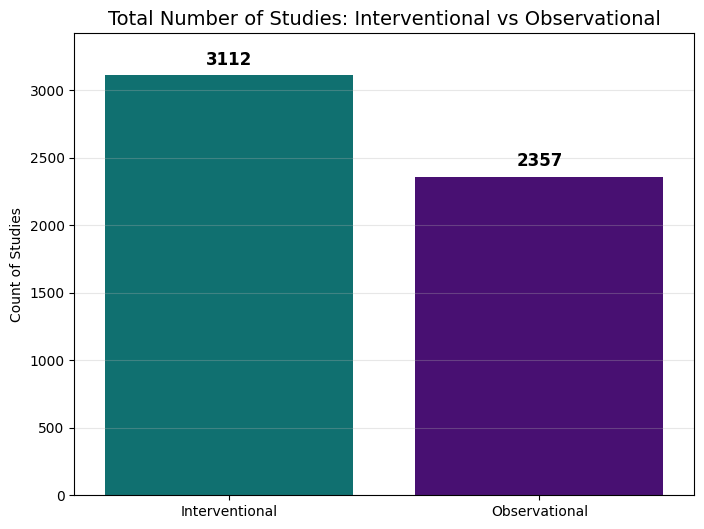

In [188]:
# Visualizing the total number of studies in each category (Interventional vs Observational)
types = ['Interventional', 'Observational']
totals = [len(df_inter), len(df_obser)]

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=types, y=totals, palette=['teal', 'indigo'])

# Adding count labels on top of the bars
for i, v in enumerate(totals):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. Labeling and aesthetics
plt.title('Total Number of Studies: Interventional vs Observational', fontsize=14)
plt.ylabel('Count of Studies')
plt.ylim(0, max(totals) * 1.1) # Dá espaço para o texto acima da barra
plt.grid(axis='y', alpha=0.3)

plt.show()

In [189]:
med_inter = df_inter['Enrollment'].median()
med_obser = df_obser['Enrollment'].median()

print(f"Interventional Median: {med_inter:.0f}")
print(f"Observational Median: {med_obser:.0f}")

Interventional Median: 120
Observational Median: 300


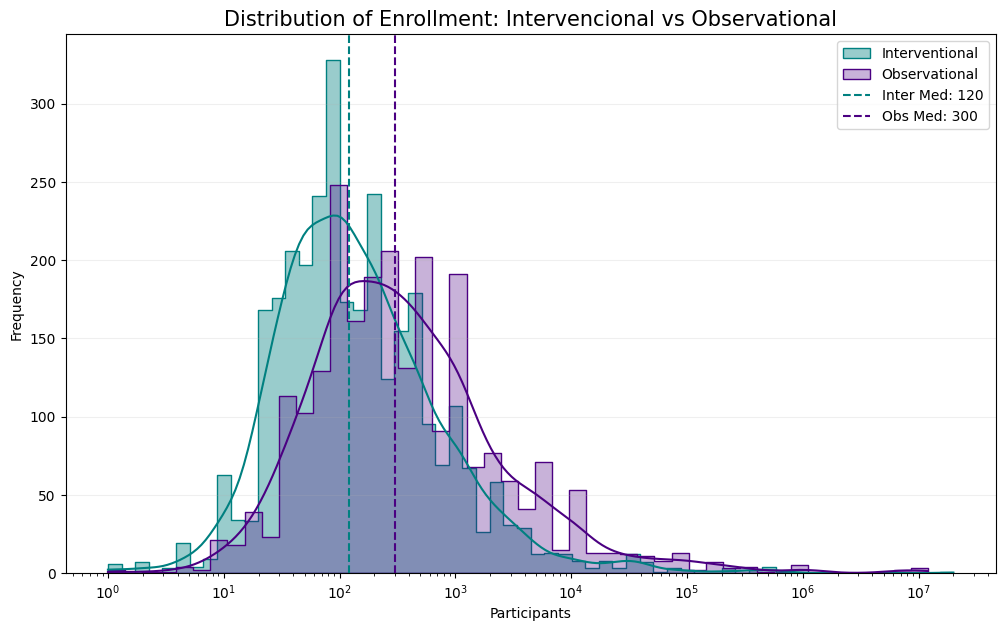

In [190]:
# Visualizing the distribution of Enrollment for Interventional and Observational studies
plt.figure(figsize=(12, 7))

# Ploting the Interventional group
sns.histplot(df_inter['Enrollment'], log_scale=True, kde=True, # logarithmization for better visualization of the distribution
             color='teal', label='Interventional', alpha=0.4, element="step")

# Ploting the Observational group
sns.histplot(df_obser['Enrollment'], log_scale=True, kde=True, # logarithmization for better visualization of the distribution
             color='indigo', label='Observational', alpha=0.3, element="step")

# Adding reference lines for the medians
plt.axvline(med_inter, color='teal', linestyle='--', label=f'Inter Med: {med_inter:.0f}')
plt.axvline(med_obser, color='indigo', linestyle='--', label=f'Obs Med: {med_obser:.0f}')

# Legend and labels
plt.title('Distribution of Enrollment: Intervencional vs Observational', fontsize=15)
plt.xlabel('Participants')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.show()

### Analysis of the Enrollment Performance (Q3)

The initial dataframe revelad a heavily skewed distribution for the Enrollment data. Even after removing the 20M participant outlier, values in the millions were persistent.

To understand the extremes, a closer look was taken at the 99th percentil, revealing that these were dominated by the Observational studies.

Data was then separated into Interventional Studides and Observational Studies, and even though the number of Interventional studies is higher, the enrollment on the observational studies was approximately twice as large (Med.= 300 vs. Med.=120). 

Inspecting the titles of the largest studies revealed that these massive numbers are tied to Apps and Big Data projects.

To conclude, technology-driven research allows projects to attract participants more easily than traditional methods. While clinical trials face logistical barriers, digital tools and database analysis enable population scale by removing physical and administrative barriers.

---

### Exploring Landscape Overview

In [191]:
# 1. Distribuição por Fase (Phases)
# Nota: Estudos Observacionais aparecerão como 'N/A'
phase_dist = df_covid['Phases'].value_counts()

# 2. Distribuição por Status do Estudo
status_dist = df_covid['Status'].value_counts()

# 3. Distribuição por Tipo de Estudo
type_dist = df_covid['Study Type'].value_counts()

# 4. Evolução Mensal (Trend Analysis)
# Criar uma coluna de Ano-Mês para ver quando os estudos começaram
df_covid['Start_Month'] = df_covid['Start Date'].dt.to_period('M')
evolution_trend = df_covid.groupby('Start_Month').size()

print("--- Landscape Overview ---")
print(f"\nDistribuição por Fase:\n{phase_dist}")
print(f"\nDistribuição por Status:\n{status_dist}")
print(f"\nEvolução Temporal (Primeiros 5 meses):\n{evolution_trend.head()}")

--- Landscape Overview ---

Distribuição por Fase:
Phases
N/A                3646
Phase 2             672
Phase 3             434
Phase 1             233
Phase 2|Phase 3     199
Phase 1|Phase 2     190
Phase 4             159
Early Phase 1        43
Name: count, dtype: int64

Distribuição por Status:
Status
Recruiting                 2707
Not yet recruiting         1004
Completed                   994
Active, not recruiting      488
Enrolling by invitation     175
Withdrawn                   107
Terminated                   74
Suspended                    27
Name: count, dtype: int64

Evolução Temporal (Primeiros 5 meses):
Start_Month
2019-12     15
2020-01     62
2020-02    102
2020-03    419
2020-04    848
Freq: M, dtype: int64


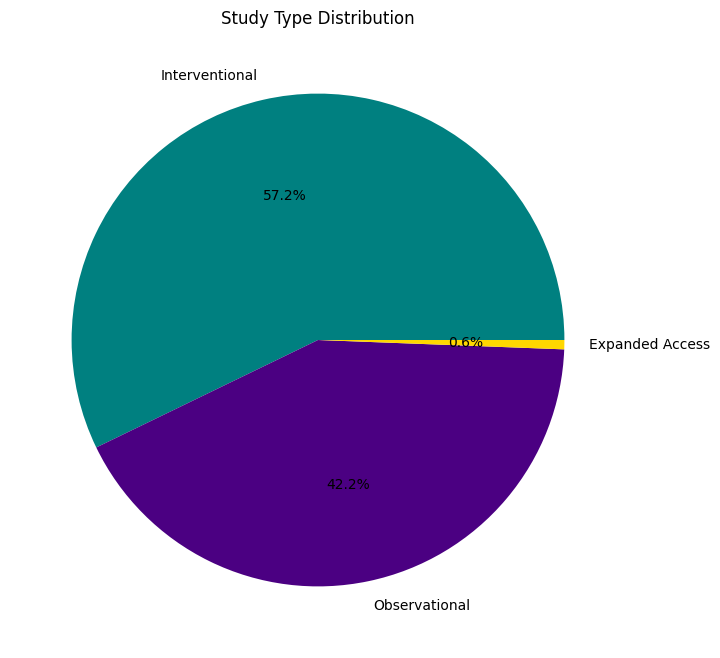

In [192]:
# Overview of the distribution of Study Type
# Here it is important to include the Expanded Access category, to have a complete picture of the landscape
count_inter = len(df_covid[df_covid['Study Type'] == 'Interventional'])
count_obser = len(df_covid[df_covid['Study Type'] == 'Observational'])
count_expanded = len(df[df['Study Type'].str.contains('Expanded Access', na=False)])

# Visualizing the distribution of Study Type using a pie chart
plt.figure(figsize=(8, 8))
plt.pie([count_inter, count_obser, count_expanded], 
        labels=['Interventional', 'Observational', 'Expanded Access'],
        autopct='%1.1f%%',
        colors=['teal', 'indigo', 'gold'])

plt.title('Study Type Distribution')
plt.show()

**Comment**: As previously concluded from the preliminary analysis, the majority of studies are Interventional (57.2), reflecting the urgency to find effective treatments and vaccines during the pandemic. 
Observational studies represent a significant share (42.2%), likely driven by the need to monitor and understand the disease's progression and long-term effects across populations. 
Expanded Access (0.6%) represents a negligible fraction, which was expected given its exceptional nature.

C:\Users\User\AppData\Local\Temp\ipykernel_27796\1413474706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=status_counts.index, x=status_counts.values, palette='magma')


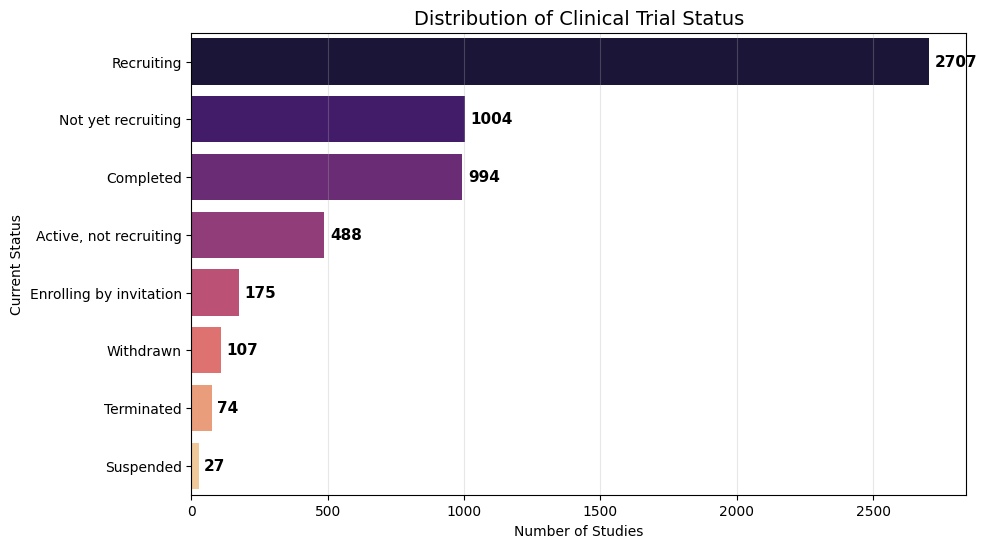

In [193]:
# Overview of the distribution of Status
# Counting the number of studies in each Status category
status_counts = df_covid['Status'].value_counts()

# Visualizing the distribution of studies by Status using a horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=status_counts.index, x=status_counts.values, palette='magma')

# Adding count labels on top of the bars
for i, v in enumerate(status_counts.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=11, fontweight='bold')

# 4. Labeling and aesthetics
plt.title('Distribution of Clinical Trial Status', fontsize=14)
plt.xlabel('Number of Studies')
plt.ylabel('Current Status')
plt.grid(axis='x', alpha=0.3)

plt.show()

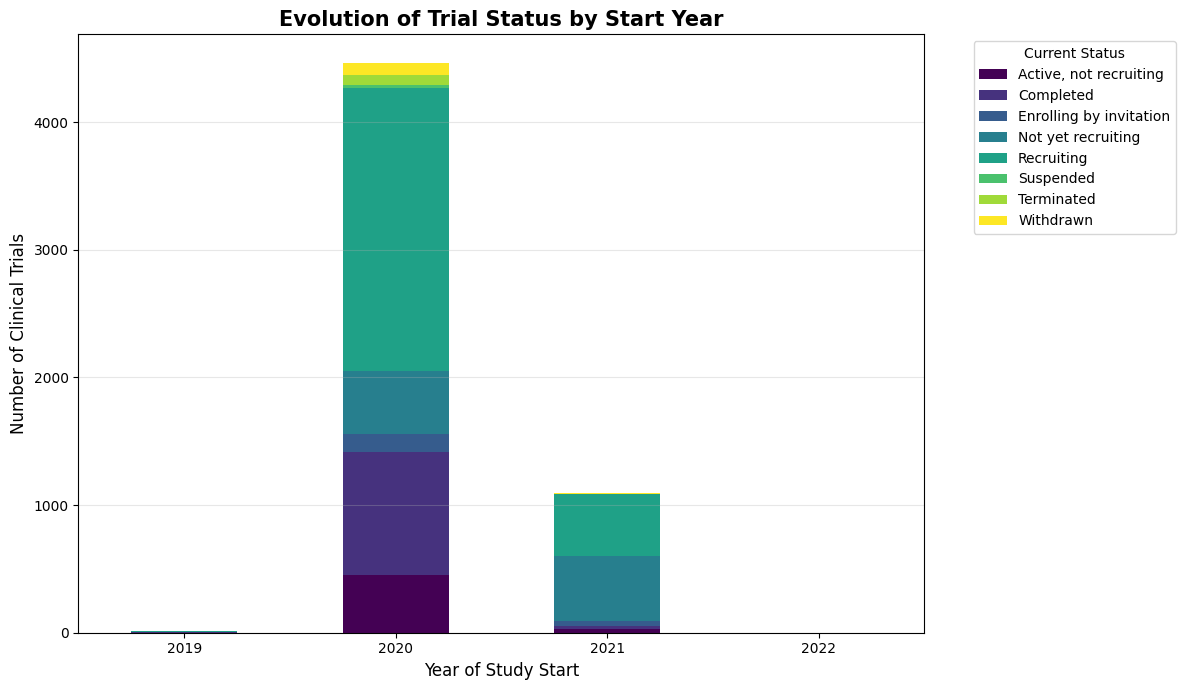

In [194]:
# Inspecting the distribution of Status by Start Date to understand the evolution of the pandemic response.
df_covid['Start Year'] = pd.to_datetime(df_covid['Start Date']).dt.year

# Creating a crosstab to see the count of each Status by Start Year
# Filtramos para os anos principais da pandemia (2020-2023) para o gráfico ficar limpo
status_evolution = pd.crosstab(df_covid['Start Year'], df_covid['Status'])

# Plotting the stacked bar chart to visualize the evolution of trial status over the years
status_evolution.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')


plt.title('Evolution of Trial Status by Start Year', fontsize=15, fontweight='bold')
plt.xlabel('Year of Study Start', fontsize=12)
plt.ylabel('Number of Clinical Trials', fontsize=12)
plt.legend(title='Current Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**: The majority of the studies are in the Recruiting and Not yet recruiting phases, and the vast majority started during 2020, which was the pandemic peak.

C:\Users\User\AppData\Local\Temp\ipykernel_27796\3264218130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=phase_counts.index, x=phase_counts.values, palette='viridis', ax=ax1)
C:\Users\User\AppData\Local\Temp\ipykernel_27796\3264218130.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=int_phase_counts.index, x=int_phase_counts.values, palette='magma', ax=ax2)


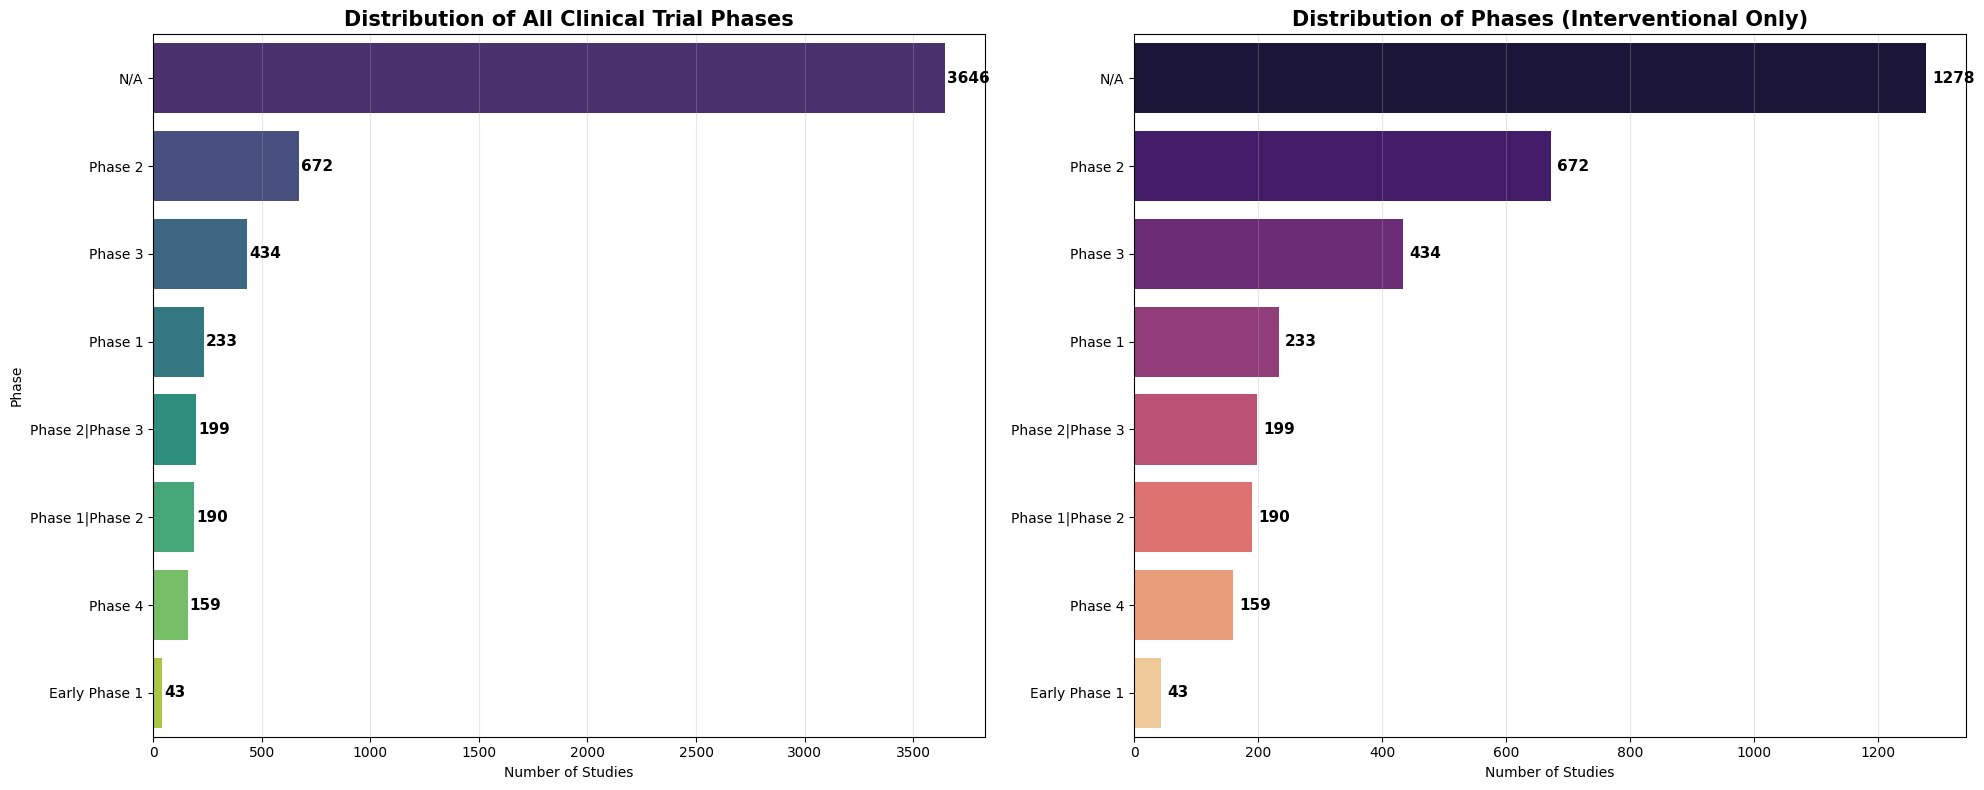

In [195]:
# Overview of the distribution of Phases
# Counting the number of studies in each Phase category
phase_counts = df_covid['Phases'].value_counts()

# Counting the number of studies in each Phase category for interventional studies only
int_phase_counts = df_covid[df_covid['Study Type'] != 'Observational']['Phases'].value_counts()

# Creating the frame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot for All Study Types ---
sns.barplot(y=phase_counts.index, x=phase_counts.values, palette='viridis', ax=ax1)
ax1.set_title('Distribution of All Clinical Trial Phases', fontsize=15, fontweight='bold')
ax1.set_xlabel('Number of Studies')
ax1.set_ylabel('Phase')
ax1.grid(axis='x', alpha=0.3)

for i, v in enumerate(phase_counts.values):
    ax1.text(v + 10, i, str(int(v)), va='center', fontsize=11, fontweight='bold')

# --- Plot for Interventional Only ---
sns.barplot(y=int_phase_counts.index, x=int_phase_counts.values, palette='magma', ax=ax2)
ax2.set_title('Distribution of Phases (Interventional Only)', fontsize=15, fontweight='bold')
ax2.set_xlabel('Number of Studies')
ax2.set_ylabel('') # Removed the Y label here to avoid repetition
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(int_phase_counts.values):
    ax2.text(v + 10, i, str(int(v)), va='center', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()



**Comment:** If looking at all trials, the majority fall under N/A (3646), which is expected given the large proportion of Observational studies in the dataset. When filtering for Interventional studies only, N/A still dominates, which may be related to the status. 

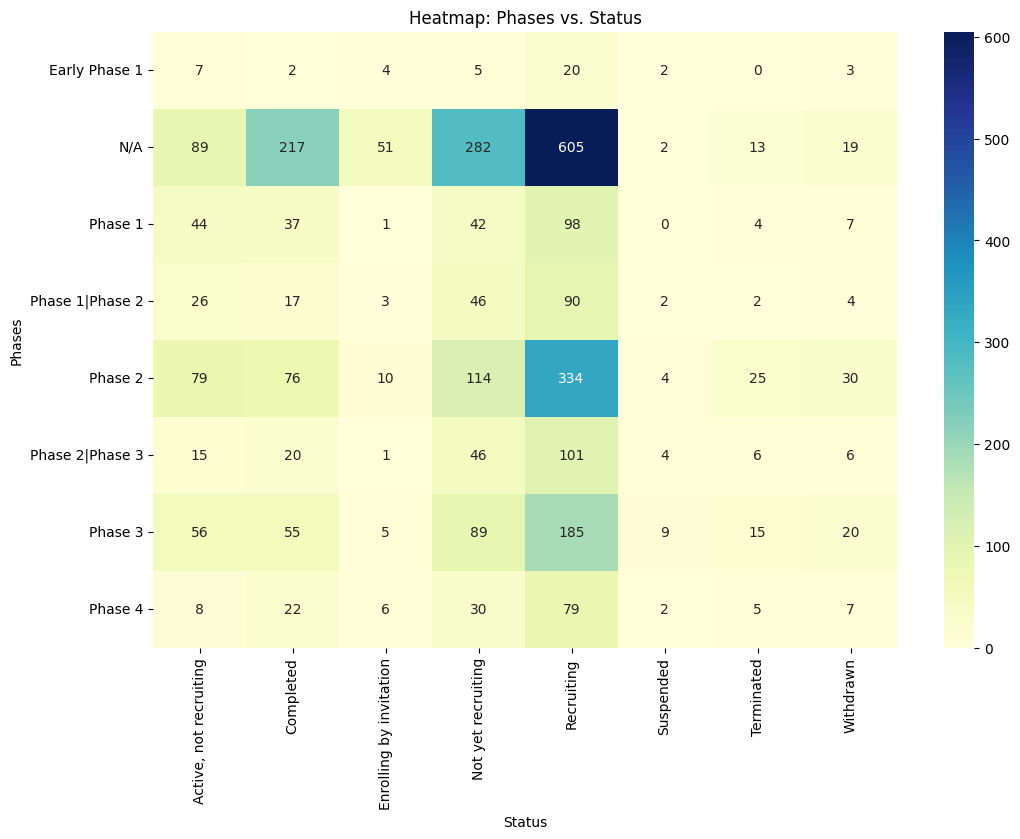

In [196]:
# Testing if the elevated number of N/A in interventional studies is related to statuses
df_inter_only = df_covid[df_covid['Study Type'] != 'Observational']

# Creating a crosstab 
ct = pd.crosstab(df_inter_only['Phases'], df_inter_only['Status'])

# Ploting a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Phases vs. Status')
plt.show()

**Comment:** The heat map shows that the majority of the N/A on Interventional studies correspondes to studies that are still recruiting, not recruiting yet and completed, which suports the previous hypothesys

C:\Users\User\AppData\Local\Temp\ipykernel_27796\2611600628.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clean.values, y=top_clean.index, palette='magma')


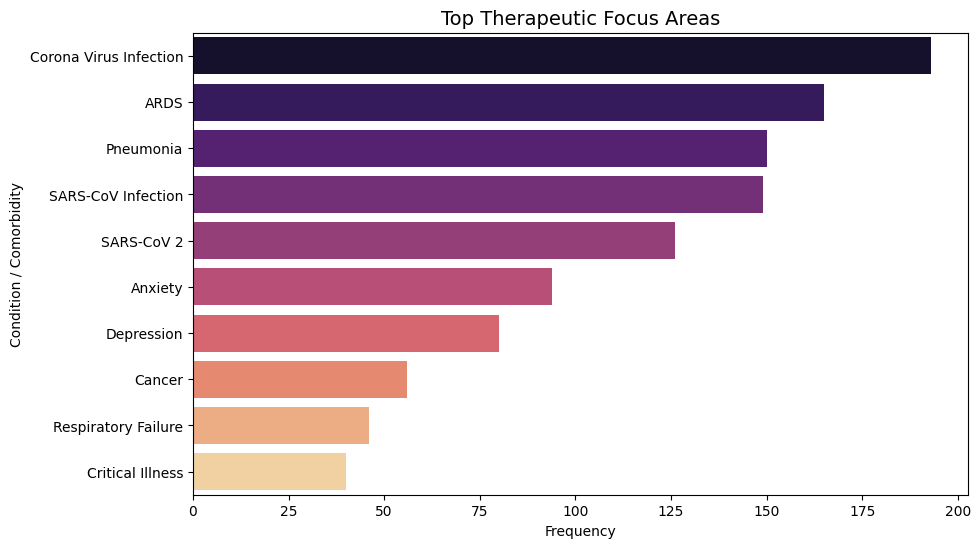

In [197]:
# Overviewing the therapeutic focus areas 
# Stripping generic COVID terms to allow a clearer view of the comorbidities and specific conditions being studied
all_conds = df_covid['Conditions'].str.split('|').explode().str.strip()

terms_to_exclude = [
    'COVID', 'Coronavirus', 'SARS-CoV-2', 'Sars-CoV2', 
    '2019-nCoV', 'Severe Acute Respiratory Syndrome Coronavirus 2'
]

# Maintaining only the conditions that do NOT contain the generic COVID terms
pattern = '|'.join(terms_to_exclude)
clean_areas = all_conds[~all_conds.str.contains(pattern, case=False, na=False)]

# Grouping similar terms that refer to the same condition
clean_areas = clean_areas.replace({
    'Pneumonia, Viral': 'Pneumonia',
    'Acute Respiratory Distress Syndrome': 'ARDS',
    'Adult Respiratory Distress Syndrome': 'ARDS'
})

# Plotting the top 10 therapeutic focus areas
top_clean = clean_areas.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_clean.values, y=top_clean.index, palette='magma')
plt.title('Top Therapeutic Focus Areas', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Condition / Comorbidity')
plt.show()

**Comment:** Since this dataset is focused on COVID-19 trials, I tried to extract insights on the comorbidities that were being studied in parallel. In general, the therapeutic focus was on respiratory conditions such as ARDS and Pneumonia, but menthal health also appears whith high predominance (Anxiety and Depression)

### Overall Trial landscape overview (Q1)

- **Study Type Distribution:** The research effort is primarily split between Interventional and Observational studies. Expanded Access programs represent a small portion.

- **Clinical Phases:** There is a high concentration of trials in Phases 2 and 3, reflecting the urgency to accelerate vaccine and drug validation. High Interventional studies with Phases=N/A were mostly linked to studies that are still recruiting or not yet recruiting, which indicates scientific interest in the disease remains highly active even after the acute pandemic phase.

- **Therapeutic Focus Areas:** After excluding generic "COVID-19" labels, the data reveals a heavy focus on Respiratory Complications (high incidence of ARDS and Pneumonia research) and Mental Health (significant number of studies on Anxiety and Depression).

---

### Failure Analysis

In [198]:
# Isolating unsuccessful studies to understand potential drivers of failure.
# Defining the statuses considered unsuccessful
unsuccessful_statuses = ['Withdrawn', 'Terminated', 'Suspended']

# Creating a new DataFrame with only the unsuccessful studies
df_failed = df_covid[df_covid['Status'].isin(unsuccessful_statuses)].copy()

# Checking results
print(f"Total de estudos isolados: {len(df_failed)}")
print("\nDistribuição por Status:")
print(df_failed['Status'].value_counts())

df_failed


Total de estudos isolados: 208

Distribuição por Status:
Status
Withdrawn     107
Terminated     74
Suspended      27
Name: count, dtype: int64


,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Start Date,Primary Completion Date,Completion Date,allocation,intervention_model,observational_model,time_perspective,masking,primary_purpose,country,Start_Month,Start Year
8,NCT04602884,Early Detection of COVID-19 Using Breath Analysis,Suspended,No Results Available,Covid19,Diagnostic Test: Breath biopsy sampling using ...,Correlation between Volatile Organic Compounds...,Scentech Medical Technologies Ltd,All,18 Years to 55 Years (Adult),N/A,50,Industry,Interventional,2020-09-22,2021-12-30,2021-12-30,Non-Randomized,Parallel Assignment,N/A,N/A,None (Open Label),Diagnostic,Israel,2020-09,2020
32,NCT04377425,COVID-19 Prevalence and Cognitive Deficits in ...,Withdrawn,No Results Available,"Neurological Diseases or Conditions|Stroke, Ac...",Diagnostic Test: COVID-19 swap test PCR,Prevalence of COVID-19 infection in consecutiv...,Aarhus University Hospital,All,"18 Years and older (Adult, Older Adult)",N/A,0,Other,Observational,2020-05-07,2020-11-29,2022-06-30,N/A,N/A,Cohort,Prospective,N/A,N/A,Denmark,2020-05,2020
227,NCT04342156,Safety And Efficacy Of Hydroxychloroquine For ...,Withdrawn,No Results Available,Coronavirus Infection|Hydroxychloroquine Adver...,Drug: Hydroxychloroquine Sulfate 200 milligram...,positive serology or reverse transcriptase (RT...,Tan Tock Seng Hospital|National Center for Inf...,All,"18 Years to 80 Years (Adult, Older Adult)",Phase 3,0,Other,Interventional,2020-04-01,2020-08-01,2020-10-01,Randomized,Parallel Assignment,N/A,N/A,None (Open Label),Prevention,Unknown,2020-04,2020
250,NCT04341441,Will Hydroxychloroquine Impede or Prevent COVI...,Terminated,No Results Available,COVID-19|Coronavirus|Coronavirus Infections|SA...,Drug: Hydroxychloroquine - Daily Dosing|Drug: ...,To determine if the use of hydroxychloroquine ...,Henry Ford Health System,All,"18 Years to 75 Years (Adult, Older Adult)",Phase 3,624,Other,Interventional,2020-04-07,2020-12-15,2020-12-15,Randomized,Parallel Assignment,N/A,N/A,"Triple (Participant, Care Provider, Investigator)",Prevention,United States,2020-04,2020
295,NCT04358835,Keto-diet for Intubated Critical Care COVID-19,Withdrawn,No Results Available,COVID-19,Dietary Supplement: Ketogenic diet|Other: stan...,Change in the partial pressure of carbon dioxi...,Johns Hopkins University,All,"18 Years to 80 Years (Adult, Older Adult)",N/A,0,Other,Interventional,2020-09-01,2021-09-01,2021-12-31,N/A,Single Group Assignment,N/A,N/A,None (Open Label),Treatment,Unknown,2020-09,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5376,NCT04441164,VERARE : Effectiveness of Virtual Motor Action...,Withdrawn,No Results Available,Weakness of the Lower Limbs,Other: Observation of Virtual Actions|Other: R...,6-minute test|Time for 10-meter test|6-minute ...,Rennes University Hospital|Institut National d...,All,"18 Years and older (Adult, Older Adult)",N/A,0,Other,Interventional,2020-08-01,2022-08-01,2023-08-01,Randomized,Parallel Assignment,N/A,N/A,None (Open Label),Supportive Care,France,2020-08,2020
5388,NCT04283825,Humanistic Care in Patients With Coronavirus D...,Withdrawn,No Results Available,Coronavirus Disease 2019,Behavioral: Psychological and physical rehabil...,Recovery Time|Self-rating depression scale|Sur...,Second Affiliated Hospital of Xi'an Jiaotong U...,All,"Child, Adult, Older Adult",N/A,0,Other,Interventional,2020-02-22,2020-04-30,2020-05-15,Non-Randomized,Parallel Assignment,N/A,N/A,None (Open Label),Supportive Care,Unknown,2020-02,2020
5414,NCT04418934,Clinical Investigation to Evaluate the Hemanex...,Withdrawn,No Results Available,Whole Blood Donations and Leukoreduction,Device: Hemanext One,% of Red Blood Cells With Hemolysis|Dual Label...,Hemanext,All,"18 Years and older (Adult, Older Adult)",Phase 2,0,Industry,Interventional,2020-07-01,2021-05-01,2021-05-01,Randomiz

C:\Users\User\AppData\Local\Temp\ipykernel_27796\3828327953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failed_by_funder.values, y=failed_by_funder.index, palette='magma')


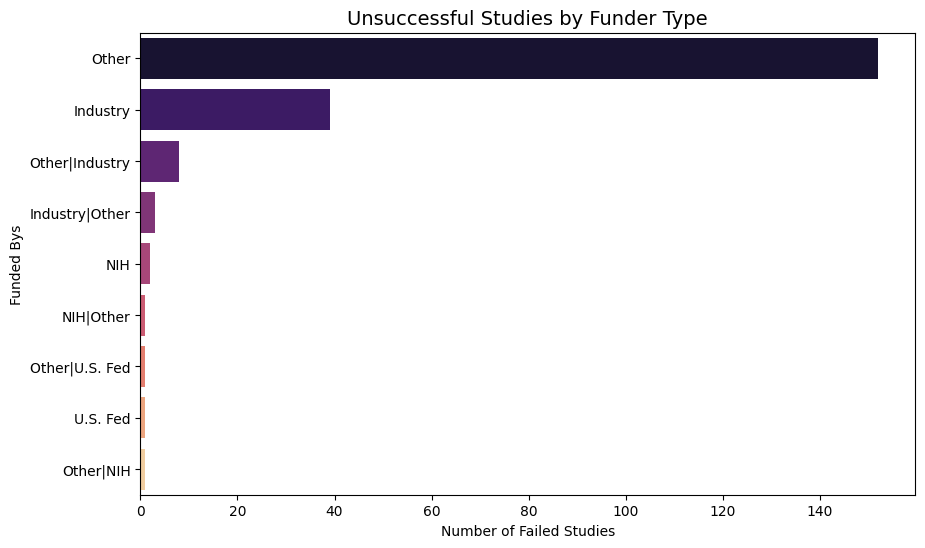

In [199]:
# Inspecting the relation between unsuccessful studies and funders
failed_by_funder = df_failed['Funded Bys'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=failed_by_funder.values, y=failed_by_funder.index, palette='magma')
plt.title('Unsuccessful Studies by Funder Type', fontsize=14)
plt.xlabel('Number of Failed Studies')
plt.show()

In [200]:
# Inspecting the top 10 sponsors to test what kind of organizations are more likely to have unsuccessful studies
df_failed['Sponsor/Collaborators'].value_counts().head(10)

Sponsor/Collaborators
Assistance Publique - Hôpitaux de Paris                                   4
Washington University School of Medicine                                  3
University of Colorado, Denver                                            3
Merck Sharp & Dohme Corp.                                                 3
Sorrento Therapeutics, Inc.                                               2
Abderrahmane Mami Hospital|Eshmoun Clinical Research Centre|Datametrix    2
Duke University                                                           2
Azidus Brasil                                                             2
NYU Langone Health                                                        2
Second Affiliated Hospital of Xi'an Jiaotong University                   2
Name: count, dtype: int64

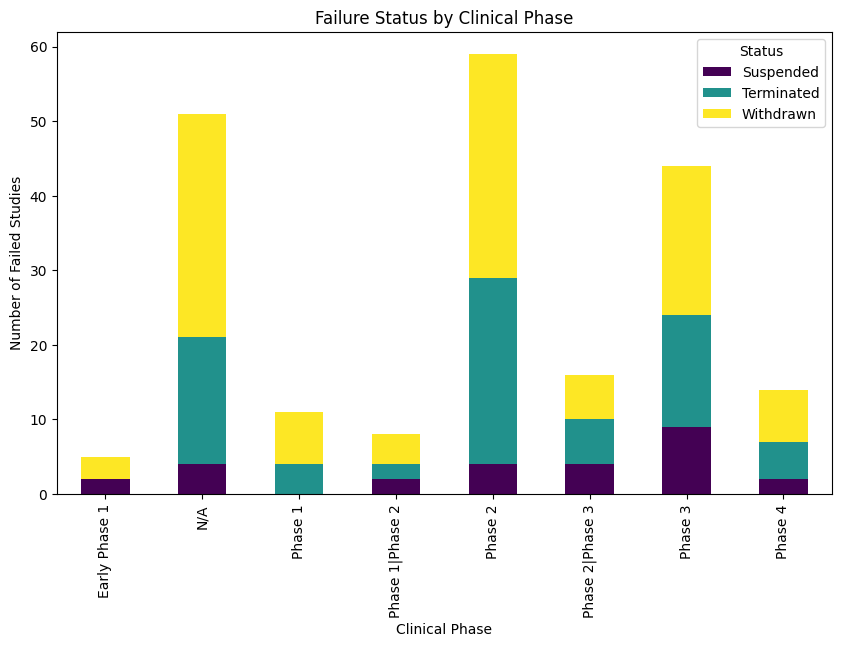

In [201]:
# Inspecting the relation between unsuccessful studies and phases
failed_phase_dist = pd.crosstab(df_failed['Phases'], df_failed['Status'])
failed_phase_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Failure Status by Clinical Phase')
plt.xlabel('Clinical Phase')
plt.ylabel('Number of Failed Studies')
plt.show()

In [202]:
# Inspecting the relation between unsuccessful studies and study type, with a focus on the N/A phase category
df_failed[df_failed['Phases'] == 'N/A']['Study Type'].value_counts()

Study Type
Interventional    34
Observational     17
Name: count, dtype: int64

In [203]:
# Inspecting the relation between unsuccessful studies and study type, with a focus on the N/A phase category
academic_terms = 'Hospital|Institute|University'

df_failed[df_failed['Phases'] == 'N/A']['Sponsor/Collaborators'].value_counts()

Sponsor/Collaborators
Second Affiliated Hospital of Xi'an Jiaotong University                                                                                                                                                                                                   2
Scentech Medical Technologies Ltd                                                                                                                                                                                                                         1
Johns Hopkins University                                                                                                                                                                                                                                  1
Mario Negri Institute for Pharmacological Research                                                                                                                                                                            

### Insights on the failure analysis (Q2)
Most of the failed studies correspond to 'Others' which is mostly composed of hospital, academic and research institutes where usually the resources are more limited. Most of the studies failed at Phase 2 an 3. Failure at Phase 2 (Exploratory) could be due to insufficient efficay. Failure at Phase 3 (Confirmatory) may be due to budgetary struggles or loss of interest. A big portion of studies fall under the N/A section. Although some correspond to observational studies which don't follow the standard clinical trial structures, many were Intervetional.

---

### Geographical analysis

C:\Users\User\AppData\Local\Temp\ipykernel_27796\2273746821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='crest')


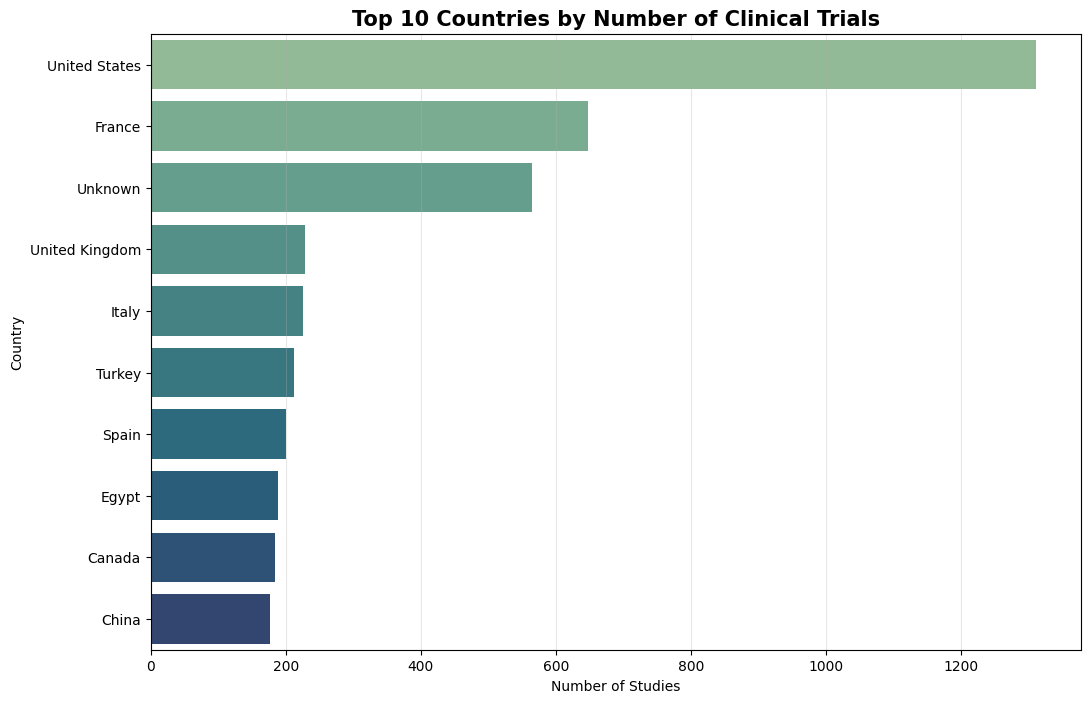

In [204]:
# Exploring the distribution of studies by country
# Selecting the top 10 countries with the most studies
country_counts = df_covid['country'].value_counts().head(10)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='crest')

plt.title('Top 10 Countries by Number of Clinical Trials', fontsize=15, fontweight='bold')
plt.xlabel('Number of Studies')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

plt.show()

In [205]:
df_covid[df_covid['country'] == 'Unknown']['Status'].value_counts()

Status
Not yet recruiting    523
Withdrawn              41
Terminated              1
Name: count, dtype: int64

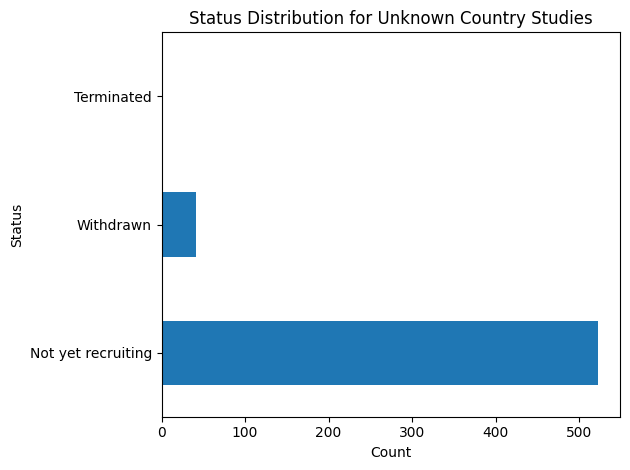

In [206]:
# Vizualizing the distribution of Status for studies with Unknown country
df_covid[df_covid['country'] == 'Unknown']['Status'].value_counts().plot(
    kind='barh',
    title='Status Distribution for Unknown Country Studies',
    xlabel='Count'
)
plt.tight_layout()
plt.show()

### Insights on the gepgraphic analysis (Q4)
The countries that led the research are the USA (by far), France and United Kingdom. A large volum of studies with Unkown location was observed. These correspond mainly to studies that are Not recruiting yet, which indicates that the location where the studies will be conducted is yet to be determined.

---

## Duration Analysis

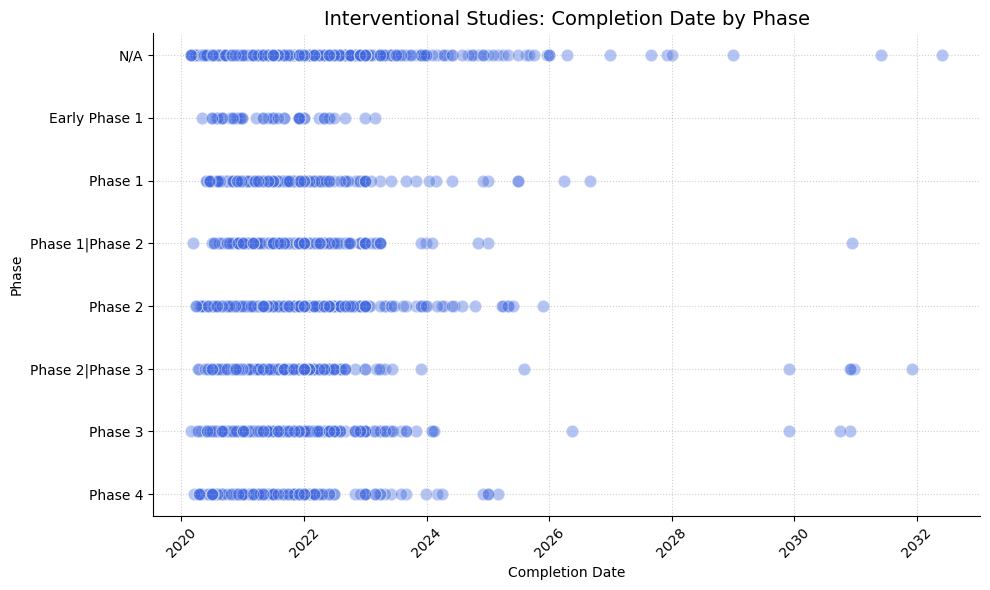

In [207]:
# Overviewing the distribution of Completion Dates by Phase, focusing on Interventional studies to understand the timeline of clinical development.
# Filtering only the Interventional studies
df_interventional = df_covid[df_covid['Study Type'] == 'Interventional'].copy()

# Indexing by N/A, Early phase1, phase 1, phase1|phase2, phase2, Phase2|phase3, Phase 3, Phase 4
phase_ind = [
    'N/A', 'Early Phase 1', 'Phase 1', 'Phase 1|Phase 2', 
    'Phase 2', 'Phase 2|Phase 3', 'Phase 3', 'Phase 4'
]
df_interventional['Phases'] = pd.Categorical(df_interventional['Phases'], categories=phase_ind, ordered=True)

# Plotting
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_interventional, 
    x='Completion Date', 
    y='Phases', 
    alpha=0.4, 
    s=80, 
    color='royalblue'
)

# Labeling and aesthetics
plt.title('Interventional Studies: Completion Date by Phase', fontsize=14)
plt.xlabel('Completion Date')
plt.ylabel('Phase')
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

sns.despine()
plt.tight_layout()
plt.show()

Total removed outliers: 12


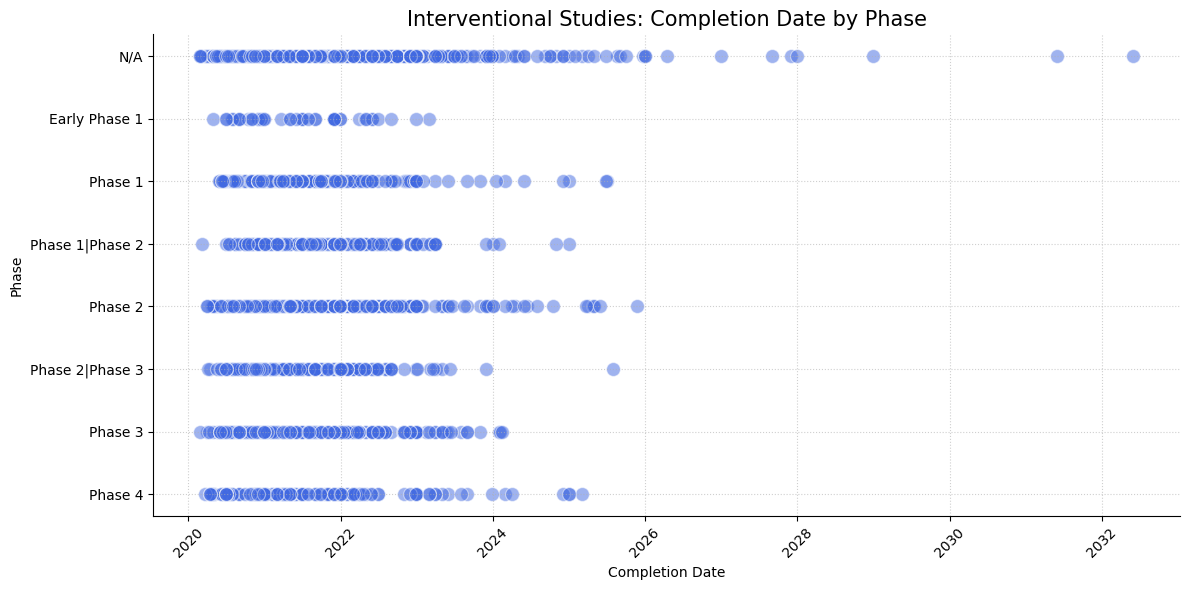

In [208]:
# Removing outliers applying a filter after 2026
outlier_rem = (df_interventional['Phases'].isin(['Phase 1', 'Phase 1|Phase 2', 'Phase 2', 'Phase 2|Phase 3','Phase 3', 'Phase 4'])) & (df_interventional['Completion Date'] > '2026-01-01')

# 3. Isolar os DataFrames
df_outliers = df_interventional[outlier_rem].copy()
df_clean = df_interventional[~outlier_rem].copy()

print(f"Total removed outliers: {len(df_outliers)}")

# Plotting
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_clean, 
    x='Completion Date', 
    y='Phases', 
    alpha=0.5, 
    s=100, 
    color='royalblue'
)

plt.title('Interventional Studies: Completion Date by Phase', fontsize=15)
plt.xlabel('Completion Date')
plt.ylabel('Phase')
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

sns.despine()
plt.tight_layout()
plt.show()

In [209]:
df_outliers[['country', 'Funded Bys', 'Sponsor/Collaborators']]

,country,Funded Bys,Sponsor/Collaborators
1079,Egypt,Other,Tanta University
2172,Unknown,Other,University of Birmingham|Christian Medical Col...
2578,Unknown,Other,Regeneris Medical
3061,Egypt,Other,Tanta University
3094,Egypt,Other,Tanta University
3186,Egypt,Other,Tanta University
3768,Egypt,Other,Tanta University
3859,Egypt,Other,Tanta University
3987,Egypt,Other,Tanta University
4128,Indonesia,Other,University of Oxford|UK Research and Innovatio...


C:\Users\User\AppData\Local\Temp\ipykernel_27796\708966762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=top_countries.values, y=top_countries.index, palette='Reds_r')
C:\Users\User\AppData\Local\Temp\ipykernel_27796\708966762.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=funded_counts.values, y=funded_counts.index, palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_27796\708966762.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x=lead_sponsors.values, y=lead_sponsors.index, 

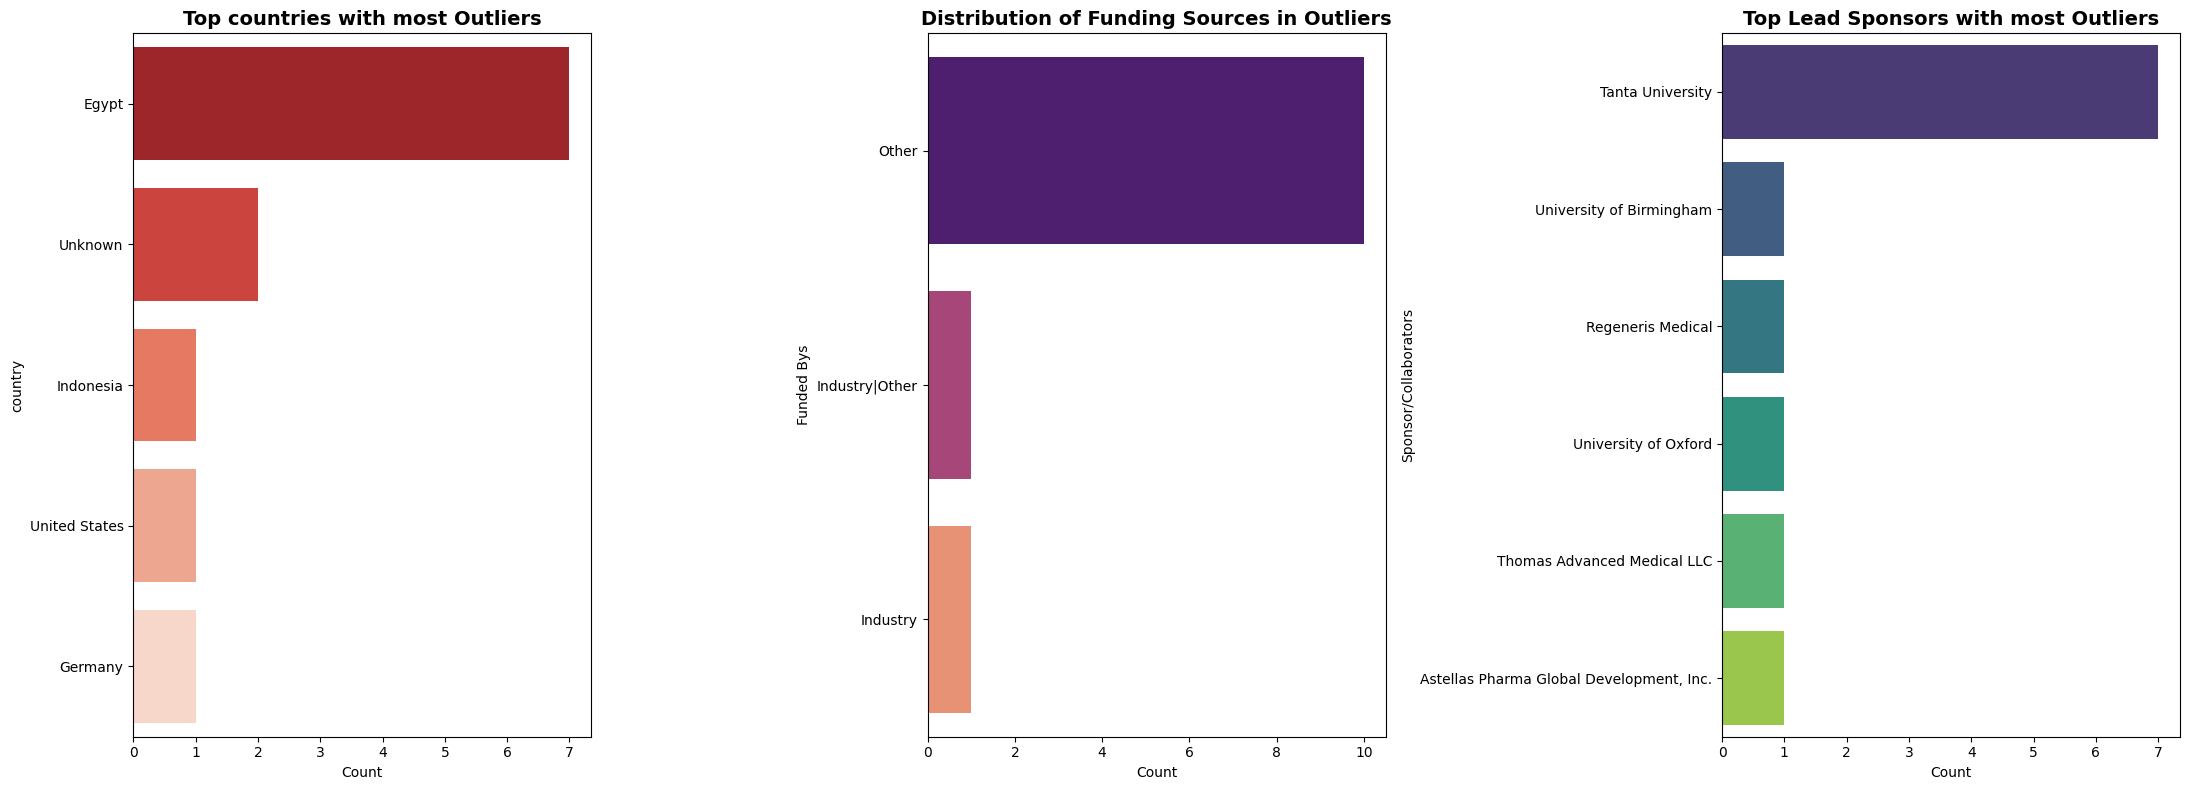

In [210]:
# Visualizing the profile of the outliers to understand if there are specific patterns in terms of country, funders, or sponsors that could explain these anomalous completion dates.
fig, axes = plt.subplots(1, 3, figsize=(22, 8)) 

# By country
top_countries = df_outliers['country'].value_counts().head(10)
sns.barplot(ax=axes[0], x=top_countries.values, y=top_countries.index, palette='Reds_r')
axes[0].set_title('Top countries with most Outliers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

# Funders
funded_counts = df_outliers['Funded Bys'].value_counts().head(10)
sns.barplot(ax=axes[1], x=funded_counts.values, y=funded_counts.index, palette='magma')
axes[1].set_title('Distribution of Funding Sources in Outliers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

# By Sponsor (Lead)
# Extracting the first appearing sponsor (lead)
lead_sponsors = df_outliers['Sponsor/Collaborators'].str.split('|').str[0].value_counts().head(10)

sns.barplot(ax=axes[2], x=lead_sponsors.values, y=lead_sponsors.index, palette='viridis')
axes[2].set_title('Top Lead Sponsors with most Outliers', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Insights on the Duration analysis (Q5)

As expected, Phase 1 and Phase 2 studies tend to have the longest durations, which is consistent with the nature these trials which assessment of safety and efficacy. The majority of studies across all phases appear to have completion dates between 2020 and 2025.
When looking specifically at the studies with unusually long completion dates extending beyond 2026, these were found to be predominantly conducted in 
Egypt, with Tanta University standing out as the lead sponsor with the highest number of outlier studies. Naturally, this is reflected in the funding soources where the majority falls under 'Other'.

In [ ]:
# Exporting
export_path = os.path.join('..', 'src', 'Data', 'processed')

df_covid.to_csv(export_path, index=False)
